# Proyecto final: Single Pixel Camera + Gaussian Splatting

## 1.1 ¿Qué es una Single Pixel Camera?

Imagina un único sensor que mira toda la escena varias veces. En cada medición una apertura codificada deja pasar la luz con un patrón distinto; el sensor registra un único número, la luz total después de esa máscara. Combinando muchas mediciones reconstruimos la imagen.

Si \`x\` es la imagen vectorizada y \`phi_k\` la máscara usada en la medición \`k\`, el modelo ideal es

$$y_k = \langle \phi_k, x \rangle.$$

\`phi_k\` pondera cada posición de la máscara, \`x\` contiene la intensidad de cada píxel y \`y_k\` es el escalar medido. Usamos patrones Hadamard \`+1/-1\`, ordenados aproximadamente por frecuencia espacial.

La figura muestra máscaras Hadamard reales y una cadena óptica conceptual. Aquí **no reproducimos la óptica**: solo simulamos la matemática de la medición y la reconstrucción 2D.

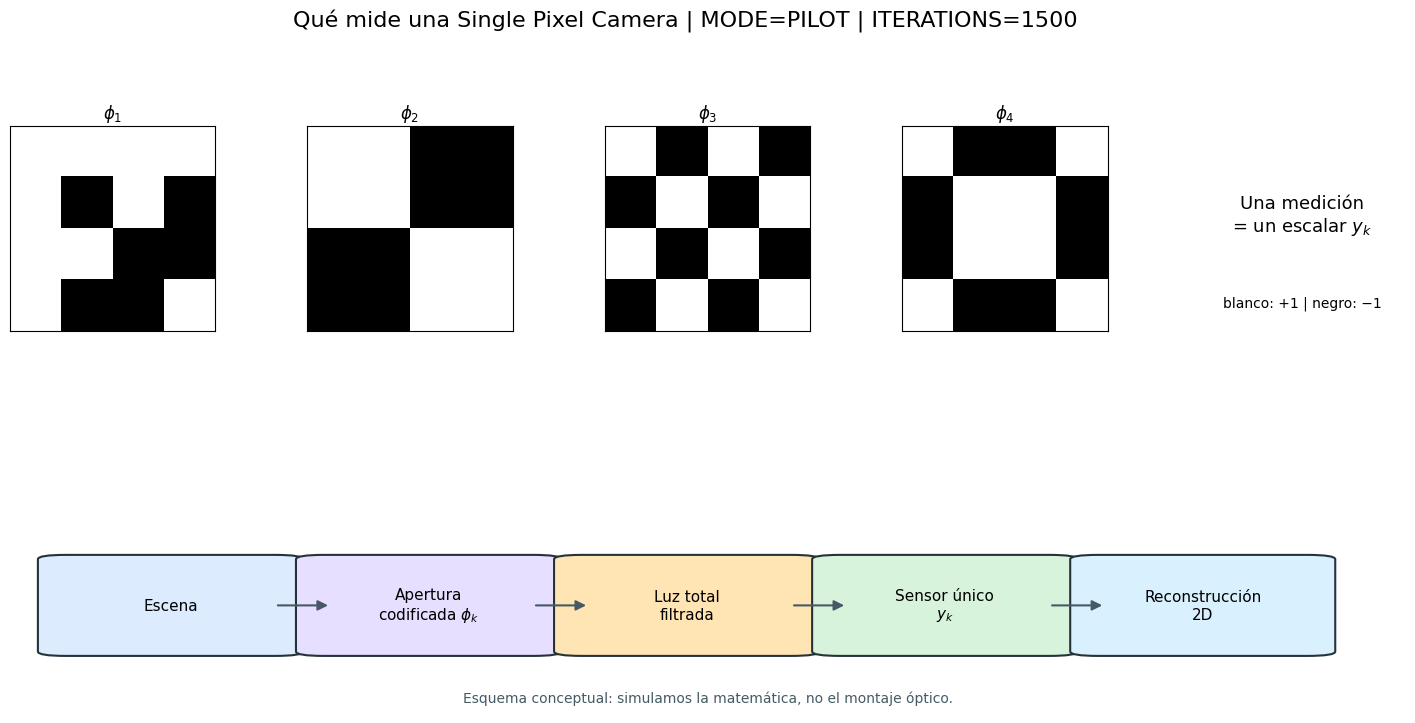

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

context = f"MODE={globals().get('MODE', '[configurar]')} | ITERATIONS={globals().get('ITERATIONS', '[configurar]')}"
fig = plt.figure(figsize=(18, 8))
grid = fig.add_gridspec(2, 5, height_ratios=[1.2, 1], wspace=0.45, hspace=0.55)
masks = [
    [[1, 1, 1, 1], [1, -1, 1, -1], [1, 1, -1, -1], [1, -1, -1, 1]],
    [[1, 1, -1, -1], [1, 1, -1, -1], [-1, -1, 1, 1], [-1, -1, 1, 1]],
    [[1, -1, 1, -1], [-1, 1, -1, 1], [1, -1, 1, -1], [-1, 1, -1, 1]],
    [[1, -1, -1, 1], [-1, 1, 1, -1], [-1, 1, 1, -1], [1, -1, -1, 1]],
]
for index, mask in enumerate(masks):
    ax = fig.add_subplot(grid[0, index])
    ax.imshow(mask, cmap='gray', vmin=-1, vmax=1, interpolation='nearest')
    ax.set_title(rf'$\phi_{{{index + 1}}}$')
    ax.set_xticks([]); ax.set_yticks([])
ax = fig.add_subplot(grid[0, 4]); ax.axis('off')
ax.text(0.5, 0.55, 'Una medición\n= un escalar $y_k$', ha='center', va='center', fontsize=13)
ax.text(0.5, 0.22, 'blanco: +1 | negro: −1', ha='center', va='center', fontsize=10)
ax = fig.add_subplot(grid[1, :]); ax.axis('off')
steps = [('Escena', '#DDEBFF'), ('Apertura\ncodificada $\phi_k$', '#E7DFFF'), ('Luz total\nfiltrada', '#FFE5B4'), ('Sensor único\n$y_k$', '#D8F3DC'), ('Reconstrucción\n2D', '#D9F0FF')]
xs = np.linspace(0.04, 0.78, len(steps))
for (label, color), x in zip(steps, xs):
    ax.add_patch(FancyBboxPatch((x, 0.28), 0.15, 0.42, boxstyle='round,pad=0.02', linewidth=1.5, edgecolor='#263238', facecolor=color, transform=ax.transAxes))
    ax.text(x + 0.075, 0.49, label, ha='center', va='center', transform=ax.transAxes, fontsize=11)
for x in xs[:-1]:
    ax.add_patch(FancyArrowPatch((x + 0.15, 0.49), (x + 0.19, 0.49), transform=ax.transAxes, arrowstyle='-|>', mutation_scale=15, linewidth=1.5, color='#455A64'))
ax.text(0.5, 0.05, 'Esquema conceptual: simulamos la matemática, no el montaje óptico.', ha='center', transform=ax.transAxes, fontsize=10, color='#455A64')
fig.suptitle(f'Qué mide una Single Pixel Camera | {context}', y=0.99, fontsize=16)
plt.show()

## 1.2 ¿Qué es Gaussian Splatting?

Imagina la escena como una nube de manchas 3D semitransparentes. Cada gaussiana tiene posición, tamaño, orientación, color y opacidad; al proyectarlas desde una cámara forman una imagen. No es una malla de triángulos ni una grilla de vóxeles.

3DGS recibe fotografías RGB multivista y poses de cámara estimadas por COLMAP. Produce una colección de gaussianas que puede renderizarse desde cámaras conocidas o nuevas. Se entrena con una pérdida fotométrica porque cada render debe parecerse a la imagen de entrada de su cámara.

## 1.3 ¿Por qué juntar SPC y Gaussian Splatting?

3DGS suele asumir fotografías limpias de una cámara convencional. Una SPC entrega imágenes reconstruidas desde pocas mediciones y puede perder detalle fino. La pregunta es cuánta degradación de adquisición tolera la reconstrucción 3D al fusionar varias vistas.

## 1.4 Pregunta experimental, hipótesis y alcance

**Pregunta:** ¿cuál es el ratio mínimo de mediciones Hadamard a partir del cual la calidad 3D deja de degradarse de forma notoria?

**Hipótesis a contrastar:** 3DGS fusiona varias vistas y puede atenuar parte de la degradación 2D. No se afirma antes de medir.

**Alcance:** una escena (truck), una base Hadamard, una semilla, imágenes reconstruidas como entrada a 3DGS y evaluación con --eval. No se estudian otras escenas, bases, ruido físico, calibración óptica ni mediciones crudas como entrada.

**Qué NO responde:** no determina el desempeño de una SPC física, no prueba generalización a otras escenas o sensores, no optimiza 3DGS para SPC y no establece un ratio universal.

## 1.5 Diseño del experimento

La única variable que se mueve es el ratio r de mediciones Hadamard. Escena, base, semilla, poses COLMAP, IMAGE_SIZE, iteraciones y protocolo de evaluación quedan fijos. resized separa el efecto de resolución del efecto de compresión SPC.

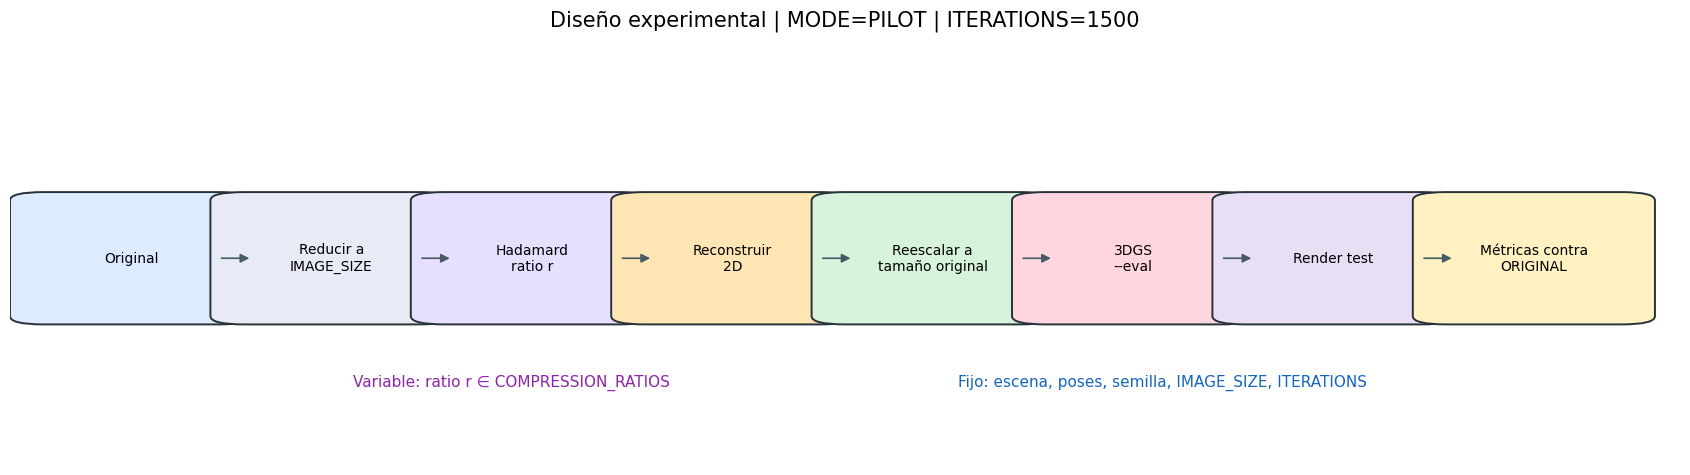

In [73]:
fig, ax = plt.subplots(figsize=(17, 4.8))
ax.axis('off')
steps = [('Original', '#DDEBFF'), ('Reducir a\nIMAGE_SIZE', '#E8EAF6'), ('Hadamard\nratio r', '#E7DFFF'), ('Reconstruir\n2D', '#FFE5B4'), ('Reescalar a\ntamaño original', '#D8F3DC'), ('3DGS\n--eval', '#FFD6E0'), ('Render test', '#E8DFF5'), ('Métricas contra\nORIGINAL', '#FFF1C1')]
xs = np.linspace(0.02, 0.86, len(steps))
for (label, color), x in zip(steps, xs):
    ax.add_patch(FancyBboxPatch((x, 0.36), 0.105, 0.28, boxstyle='round,pad=0.02', linewidth=1.4, edgecolor='#263238', facecolor=color, transform=ax.transAxes))
    ax.text(x + 0.0525, 0.50, label, ha='center', va='center', transform=ax.transAxes, fontsize=10)
for x in xs[:-1]:
    ax.add_patch(FancyArrowPatch((x + 0.105, 0.50), (x + 0.125, 0.50), transform=ax.transAxes, arrowstyle='-|>', mutation_scale=13, linewidth=1.2, color='#455A64'))
ax.text(0.30, 0.19, 'Variable: ratio r ∈ COMPRESSION_RATIOS', ha='center', transform=ax.transAxes, fontsize=11, color='#8E24AA')
ax.text(0.69, 0.19, 'Fijo: escena, poses, semilla, IMAGE_SIZE, ITERATIONS', ha='center', transform=ax.transAxes, fontsize=11, color='#1565C0')
context = f"MODE={globals().get('MODE', '[configurar]')} | ITERATIONS={globals().get('ITERATIONS', '[configurar]')}"
fig.suptitle(f'Diseño experimental | {context}', y=0.98, fontsize=15)
plt.tight_layout()
plt.show()

## 1.6 Guía de lectura de métricas

- **PSNR (dB):** error fotométrico; más alto es mejor.
- **SSIM (0 a 1):** similitud de estructura; más cerca de 1 es mejor.
- **LPIPS:** distancia perceptual; más bajo es mejor.

## 1. Dependencias, GPT y configuración de la máquina

### ¿Este notebook utiliza GPT?

No. El notebook no utiliza GPT, la API de OpenAI ni otro modelo generativo durante la ejecución. La simulación SPC, la reconstrucción Hadamard y las métricas son cálculos deterministas realizados con Python, NumPy y SciPy. GPT puede haber servido como apoyo externo para redactar o depurar el código, pero no interviene en los resultados experimentales.

### Librerías principales

| Librería | Uso en el proyecto |
|---|---|
| `numpy` | arreglos, imágenes y operaciones numéricas |
| `scipy` | base Hadamard y transformaciones |
| `Pillow` | lectura, redimensionamiento LANCZOS y guardado de imágenes |
| `scikit-image` | PSNR y SSIM |
| `matplotlib` | visualización de vistas y errores |
| `pandas` | tablas y archivos `metrics.csv` |
| `tqdm` | progreso al procesar las 251 vistas |
| `PyTorch` + CUDA | necesarios principalmente para entrenar Gaussian Splatting; esta primera mitad puede ejecutarse en CPU |
| `torchvision` | utilidades de visión y transformaciones para pipelines basados en PyTorch; opcional aquí |
| `opencv-python` | alternativa para lectura, conversión y procesamiento de imágenes; opcional aquí |
| `plyfile` | lectura/escritura de nubes de puntos y archivos PLY; útil en la etapa 3DGS |

### Máquina virtual de Colab

Colab no garantiza una máquina fija: la RAM, GPU/VRAM, espacio local, versión de Python y disponibilidad de CUDA dependen de la sesión y del tipo de cuenta. Por eso el notebook imprime los recursos reales al ejecutarse. Como referencia práctica, esta primera mitad funciona con CPU y una VM con RAM moderada; para entrenar 3DGS conviene una GPU con VRAM suficiente, al menos varios GB libres de disco local y guardar resultados en Drive. El disco `/content` es temporal y se pierde al reiniciar la sesión; Drive se usa para conservar el ZIP y los resultados.

In [74]:
# En una sesión nueva de Colab, descomenta si alguna importación falla.
# No reinstalamos PyTorch por defecto: Colab normalmente ya trae una versión
# compatible con su runtime CUDA y forzar otra puede romper el entorno.
# !pip -q install numpy scipy matplotlib pillow scikit-image pandas tqdm psutil

In [75]:
from pathlib import Path
import shutil
import zipfile
import sys
import platform
import subprocess
import struct
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from scipy.linalg import hadamard
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from tqdm.auto import tqdm

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['image.cmap'] = 'gray'
np.random.seed(449)
print('Entorno listo.')

Entorno listo.


In [76]:
# Diagnóstico de la VM local de Colab. Los valores pueden cambiar entre sesiones.
import shutil

def gibibytes(value):
    return value / (1024 ** 3)

print('Python:', sys.version.split()[0])
print('Sistema:', platform.platform())

try:
    import psutil
    memory = psutil.virtual_memory()
    print(f'RAM total: {gibibytes(memory.total):.2f} GB')
    print(f'RAM disponible: {gibibytes(memory.available):.2f} GB')
except ImportError:
    print('RAM: instala psutil para mostrarla automáticamente.')

try:
    import torch
    print('PyTorch:', torch.__version__)
    print('CUDA compilada en PyTorch:', torch.version.cuda or 'no disponible')
    if torch.cuda.is_available():
        device = torch.cuda.current_device()
        properties = torch.cuda.get_device_properties(device)
        print('GPU:', properties.name)
        print(f'VRAM total: {gibibytes(properties.total_memory):.2f} GB')
    else:
        print('GPU: no disponible; se usará CPU para esta etapa.')
except ImportError:
    print('PyTorch: no instalado; no es necesario para la simulación SPC.')

disk = shutil.disk_usage('/content')
print(f'Disco local /content: {gibibytes(disk.free):.2f} GB libres de {gibibytes(disk.total):.2f} GB')

Python: 3.11.13
Sistema: Linux-6.6.122+-x86_64-with-glibc2.35
RAM total: 12.67 GB
RAM disponible: 8.56 GB
PyTorch: 2.6.0+cu124
CUDA compilada en PyTorch: 12.4
GPU: Tesla T4
VRAM total: 14.56 GB
Disco local /content: 188.51 GB libres de 241.91 GB


## 2. Montar Drive y localizar el dataset

La siguiente celda asume que descargaste `tandt_db.zip` en `Mi unidad/inf479/`. Si lo guardaste en otra carpeta, cambia solamente `DRIVE_PROJECT`. El notebook puede trabajar tanto con el ZIP como con una carpeta ya descomprimida.

In [77]:
from google.colab import drive
drive.mount('/content/drive')
DRIVE_PROJECT = Path('/content/drive/MyDrive/inf479')
ZIP_PATH = DRIVE_PROJECT / 'tandt_db.zip'
EXTRACT_ROOT = DRIVE_PROJECT / 'tandt_db_extracted'
SCENE_NAME = 'truck'
LOCAL_SCENE = Path('/content') / SCENE_NAME
RESULTS_ROOT = DRIVE_PROJECT / 'proyecto_final_resultados'

MODE = 'PILOT'  # 'PILOT' o 'FULL'
MODE = MODE.upper()
if MODE not in {'PILOT', 'FULL'}:
    raise ValueError("MODE debe ser 'PILOT' o 'FULL'.")
MODE_SETTINGS = {'PILOT': {'VIEW_LIMIT': 30, 'ITERATIONS': 1500}, 'FULL': {'VIEW_LIMIT': None, 'ITERATIONS': 7000}}
VIEW_LIMIT = MODE_SETTINGS[MODE]['VIEW_LIMIT']
ITERATIONS = MODE_SETTINGS[MODE]['ITERATIONS']
FORCE_RETRAIN = True
USE_EVAL_SPLIT = True
IMAGE_SIZE = (64, 64)
COMPRESSION_RATIOS = [0.05, 0.10, 0.25, 0.50]
DEMO_RATIO = 0.25
RUN_TAG = f'{MODE.lower()}_iter{ITERATIONS}'
RUN_ROOT = RESULTS_ROOT / RUN_TAG
DRIVE_PROJECT.mkdir(parents=True, exist_ok=True)
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
RUN_ROOT.mkdir(parents=True, exist_ok=True)
print('Modo:', MODE, '| Vistas:', VIEW_LIMIT or 'todas', '| Iteraciones:', ITERATIONS)
print('Resultados aislados en:', RUN_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modo: PILOT | Vistas: 30 | Iteraciones: 1500
Resultados aislados en: /content/drive/MyDrive/inf479/proyecto_final_resultados/pilot_iter1500


In [78]:
# Espacio visible después de montar Drive. El espacio de /content sigue siendo temporal.
drive_disk = shutil.disk_usage('/content/drive')
print(f'Drive montado: {gibibytes(drive_disk.free):.2f} GB libres según el sistema')
print('Nota: el límite real de Drive depende de la cuota de tu cuenta.')

Drive montado: 179.08 GB libres según el sistema
Nota: el límite real de Drive depende de la cuota de tu cuenta.


In [79]:
def find_scene(root: Path, scene_name: str) -> Path | None:
    """Encuentra una carpeta de escena aunque el ZIP tenga un nivel extra."""
    direct = [root / scene_name, root / 'tandt' / scene_name]
    for candidate in direct:
        if candidate.is_dir():
            return candidate
    if root.exists():
        for candidate in root.rglob('*'):
            if candidate.is_dir() and candidate.name.lower() == scene_name.lower():
                return candidate
    return None

# Descomprime una sola vez en Drive si todavía no existe la carpeta de escena.
scene_on_drive = find_scene(EXTRACT_ROOT, SCENE_NAME)
if scene_on_drive is None and ZIP_PATH.exists():
    EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
    print('Descomprimiendo dataset; esto puede tardar unos minutos...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_ROOT)
    scene_on_drive = find_scene(EXTRACT_ROOT, SCENE_NAME)

if scene_on_drive is None:
    raise FileNotFoundError(
        f'No encontré la escena {SCENE_NAME!r}. Revisa DRIVE_PROJECT, ZIP_PATH y el nombre de la escena.'
    )

# Copiar la escena a la VM local hace que leer muchas imágenes sea más rápido que hacerlo desde Drive.
if LOCAL_SCENE.exists():
    shutil.rmtree(LOCAL_SCENE)
shutil.copytree(scene_on_drive, LOCAL_SCENE)
print('Escena en Drive:', scene_on_drive)
print('Copia local:', LOCAL_SCENE)

Escena en Drive: /content/drive/MyDrive/inf479/tandt_db_extracted/tandt/truck
Copia local: /content/truck


## 3. Inspeccionar las vistas disponibles

Gaussian Splatting necesita varias vistas de una misma escena. Aquí no capturamos fotos nuevas: reutilizamos las vistas RGB del dataset `truck` como entrada convencional y simulamos sobre ellas la adquisición de un sensor de un solo píxel. Las poses/cámaras del dataset se conservan para la etapa posterior.

ADVERTENCIA: 2 poses no tienen imagen local; se ignorarán.
Vistas con pose COLMAP: 249 | seleccionadas: 30
Ejemplo de alineación: [('01.jpg', '000001.jpg'), ('02.jpg', '000009.jpg'), ('03.jpg', '000018.jpg'), ('04.jpg', '000026.jpg'), ('05.jpg', '000035.jpg')]
Vista de referencia: /content/truck/images/000030.jpg


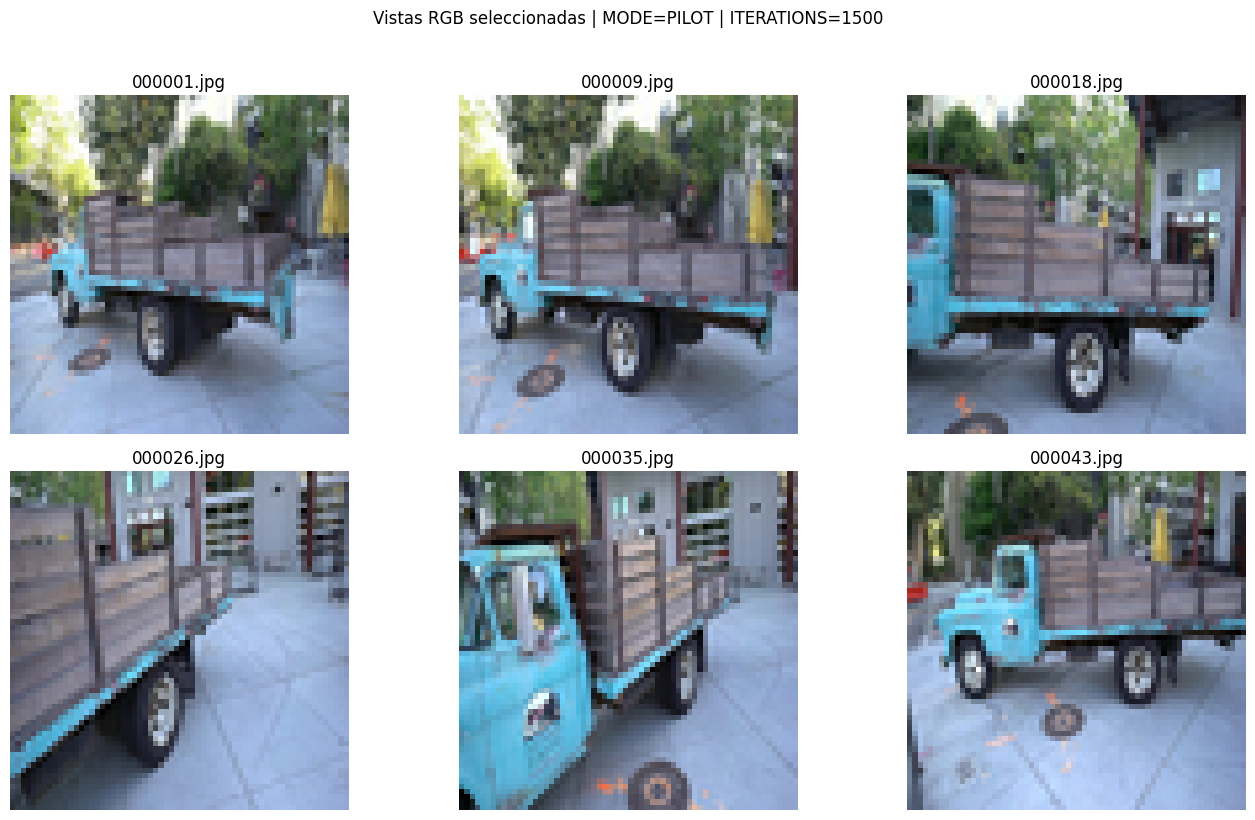

In [80]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

def read_colmap_image_names(images_bin: Path):
    """Lee únicamente los nombres de imagen de COLMAP sin modificar el archivo."""
    names = []
    with open(images_bin, 'rb') as file:
        count_bytes = file.read(8)
        if len(count_bytes) != 8:
            raise RuntimeError(f'images.bin inválido o vacío: {images_bin}')
        count = struct.unpack('<Q', count_bytes)[0]
        for _ in range(count):
            header = file.read(68)  # IMAGE_ID, qvec, tvec y CAMERA_ID
            if len(header) != 68:
                raise RuntimeError(f'images.bin truncado: {images_bin}')
            name_bytes = bytearray()
            while True:
                byte = file.read(1)
                if not byte:
                    raise RuntimeError(f'No encontré el fin del nombre en {images_bin}')
                if byte == b'\x00':
                    break
                name_bytes.extend(byte)
            n_points_bytes = file.read(8)
            if len(n_points_bytes) != 8:
                raise RuntimeError(f'images.bin truncado al leer puntos: {images_bin}')
            n_points = struct.unpack('<Q', n_points_bytes)[0]
            file.seek(24 * n_points, 1)
            names.append(name_bytes.decode('utf-8'))
    return names

images_dir = LOCAL_SCENE / 'images'
images_bin = LOCAL_SCENE / 'sparse' / '0' / 'images.bin'
if not images_dir.is_dir() or not images_bin.is_file():
    raise FileNotFoundError(f'La escena debe tener images/ y sparse/0/images.bin: {LOCAL_SCENE}')
available_images = sorted(p for p in images_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)
if not available_images:
    raise FileNotFoundError(f'No encontré imágenes dentro de {images_dir}')

def exact_image_key(name):
    return Path(name).name.casefold()

def normalized_image_key(name):
    # La equivalencia numérica es solo un fallback; no debe colapsar
    # nombres distintos como frame1.jpg y view0001.jpg.
    stem = Path(name).stem.casefold()
    # El índice puede estar al final o en medio: frame_00001_color.jpg.
    numeric_suffixes = re.findall(r'\d+', stem)
    numeric_suffix = numeric_suffixes[-1] if numeric_suffixes else None
    if numeric_suffix:
        return ('numeric', str(int(numeric_suffix)))
    return ('text', stem)

# Primero exigimos el nombre exacto. La equivalencia numérica solo se usa
# cuando la clave es inequívoca entre poses COLMAP e imágenes locales.
pose_names = read_colmap_image_names(images_bin)
by_exact_name = {}
by_fallback_key = {}
for path in available_images:
    by_exact_name.setdefault(exact_image_key(path.name), []).append(path)
    by_fallback_key.setdefault(normalized_image_key(path.name), []).append(path)
pose_aligned_images = []
pose_name_by_path = {}
missing_pose_files = []
ambiguous_pose_names = []
used_paths = set()
for pose_name in pose_names:
    exact_candidates = [path for path in by_exact_name.get(exact_image_key(pose_name), []) if path not in used_paths]
    if len(exact_candidates) == 1:
        selected_path = exact_candidates[0]
    elif len(exact_candidates) > 1:
        ambiguous_pose_names.append((pose_name, exact_candidates))
        continue
    else:
        fallback_key = normalized_image_key(pose_name)
        fallback_candidates = [path for path in by_fallback_key.get(fallback_key, []) if path not in used_paths]
        if len(fallback_candidates) == 1:
            selected_path = fallback_candidates[0]
        elif not fallback_candidates:
            missing_pose_files.append(pose_name)
            continue
        else:
            ambiguous_pose_names.append((pose_name, fallback_candidates))
            continue
    pose_aligned_images.append(selected_path)
    pose_name_by_path[selected_path] = Path(pose_name).name
    used_paths.add(selected_path)
    del selected_path
if not pose_aligned_images:
    local_examples = [path.name for path in available_images[:10]]
    raise RuntimeError(f'Ninguna imagen de {images_dir} coincide con {images_bin}. Ejemplos COLMAP: {pose_names[:5]}; ejemplos locales: {local_examples}')
if missing_pose_files:
    print(f'ADVERTENCIA: {len(missing_pose_files)} poses no tienen imagen local; se ignorarán.')
if ambiguous_pose_names:
    print(f'ADVERTENCIA: {len(ambiguous_pose_names)} poses tienen nombres ambiguos; se ignorarán.')
all_image_files = pose_aligned_images
if VIEW_LIMIT is None or VIEW_LIMIT >= len(all_image_files):
    selected_indices = np.arange(len(all_image_files), dtype=int)
else:
    # Submuestreo uniforme sobre imágenes que sí tienen pose COLMAP.
    selected_indices = np.unique(np.linspace(0, len(all_image_files) - 1, VIEW_LIMIT, dtype=int))
image_files = [all_image_files[index] for index in selected_indices]
REFERENCE_INDEX = len(image_files) // 2
REFERENCE_FILE = image_files[REFERENCE_INDEX]
with Image.open(REFERENCE_FILE) as source:
    REFERENCE_ORIGINAL_SIZE = source.size
print(f'Vistas con pose COLMAP: {len(all_image_files)} | seleccionadas: {len(image_files)}')
print('Ejemplo de alineación:', [(Path(pose_names[i]).name, image_files[i].name) for i in range(min(5, len(image_files)))])
print('Vista de referencia:', REFERENCE_FILE)

def load_image(path: Path, size=IMAGE_SIZE):
    with Image.open(path) as source:
        return np.asarray(source.convert('RGB').resize(size, Image.Resampling.LANCZOS), dtype=np.float32) / 255.0

def load_original_image(path: Path):
    with Image.open(path) as source:
        return np.asarray(source.convert('RGB'), dtype=np.float32) / 255.0

def resize_to_original_resolution(image, original_size):
    image_uint8 = np.round(np.clip(image, 0, 1) * 255).astype(np.uint8)
    return np.asarray(Image.fromarray(image_uint8, mode='RGB').resize(original_size, Image.Resampling.LANCZOS), dtype=np.float32) / 255.0

def save_at_original_resolution(image, source_path, output_path):
    with Image.open(source_path) as source:
        original_size = source.size
    resized = resize_to_original_resolution(image, original_size)
    Image.fromarray(np.round(resized * 255).astype(np.uint8), mode='RGB').save(output_path)
    return resized

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, path in zip(axes.flat, image_files[:6]):
    ax.imshow(load_image(path)); ax.set_title(path.name); ax.axis('off')
for ax in axes.flat[min(6, len(image_files)):]:
    ax.axis('off')
plt.suptitle(f'Vistas RGB seleccionadas | MODE={MODE} | ITERATIONS={ITERATIONS}', y=1.02)
plt.tight_layout()

### Vista de referencia

Esta es la imagen que seguiremos a través de todo el pipeline para ilustrar cada paso.

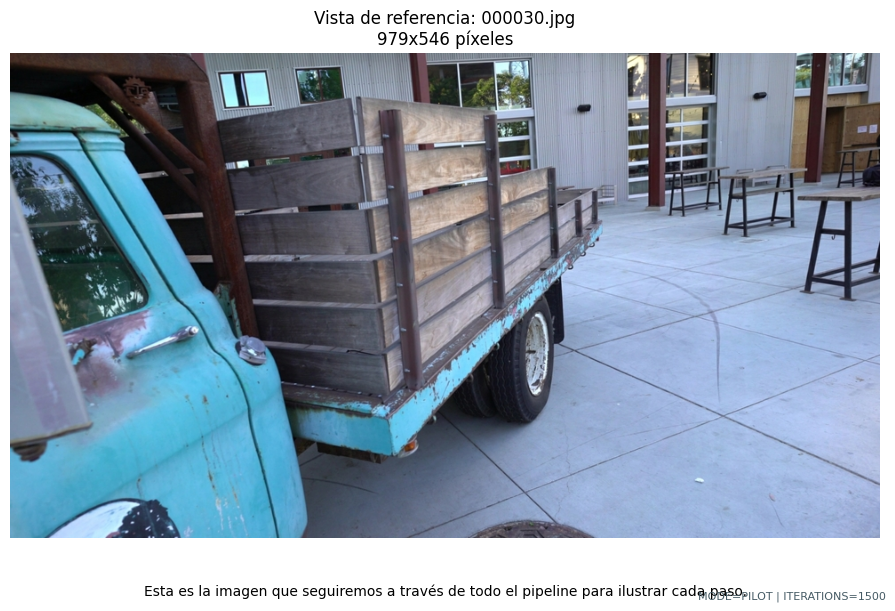

In [81]:
reference_original = load_original_image(REFERENCE_FILE)
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(reference_original)
ax.set_title(
    f'Vista de referencia: {REFERENCE_FILE.name}\n'
    f'{reference_original.shape[1]}x{reference_original.shape[0]} píxeles'
)
ax.axis('off')
fig.text(0.5, 0.02, 'Esta es la imagen que seguiremos a través de todo el pipeline para ilustrar cada paso.', ha='center')
plt.tight_layout(rect=(0, 0.05, 1, 1))

if 'fig' in globals() and 'MODE' in globals():
    fig.text(0.99, 0.01, f'MODE={MODE} | ITERATIONS={ITERATIONS}', ha='right', va='bottom', fontsize=8, color='#455A64')


## 4. Simular la Single Pixel Camera con patrones Hadamard

**Puente narrativo:** primero convertiremos la vista de referencia a una resolución pequeña y luego la expresaremos en una base Hadamard. Así hacemos explícito qué información espacial está disponible antes de simular las mediciones comprimidas.

Usaremos una base Hadamard 2D. Cada elemento de la base es una máscara con valores $+1/-1$; el producto interno entre esa máscara y la imagen es una medición de un solo píxel.

Para reconstruir con una fracción `r` de mediciones, conservamos los patrones de menor frecuencia espacial y colocamos en cero los coeficientes no medidos. Con `r=1.0` la transformación es completa; con `r<1.0` aparece compresión y pérdida de detalle. Se procesan los tres canales RGB por separado para que las imágenes sigan siendo compatibles con Gaussian Splatting.

In [82]:
def make_hadamard_basis(size: int):
    if size & (size - 1):
        raise ValueError('IMAGE_SIZE debe ser potencia de dos para Hadamard.')
    h = hadamard(size).astype(np.float32) / np.sqrt(size)
    # Orden aproximado por frecuencia: menos cambios de signo primero.
    changes = np.sum(h[:, 1:] != h[:, :-1], axis=1)
    order_1d = np.argsort(changes, kind='stable')
    pairs = [(i, j) for i in order_1d for j in order_1d]
    pairs.sort(key=lambda ij: (changes[ij[0]] + changes[ij[1]],
                               max(changes[ij[0]], changes[ij[1]])))
    return h, pairs

H, HADAMARD_ORDER = make_hadamard_basis(IMAGE_SIZE[0])
print('Base Hadamard:', H.shape, '| mediciones completas:', len(HADAMARD_ORDER))

def spc_measurements(image: np.ndarray, ratio: float):
    """Simula y_k=<phi_k,x> y devuelve las mediciones seleccionadas."""
    if image.shape[:2] != (H.shape[0], H.shape[1]):
        raise ValueError(f'La imagen debe tener tamaño {(H.shape[0], H.shape[1])}.')
    ratio = float(np.clip(ratio, 1 / len(HADAMARD_ORDER), 1.0))
    n_measurements = max(1, int(round(ratio * len(HADAMARD_ORDER))))
    coefficients = np.stack([H @ image[..., c] @ H.T for c in range(image.shape[-1])], axis=-1)
    selected = HADAMARD_ORDER[:n_measurements]
    measurements = np.stack([coefficients[i, j] for i, j in selected], axis=0)
    return measurements, selected, coefficients.shape

def spc_reconstruct(measurements: np.ndarray, selected, coefficient_shape):
    coefficients = np.zeros(coefficient_shape, dtype=np.float32)
    for measurement, (i, j) in zip(measurements, selected):
        coefficients[i, j] = measurement
    reconstruction = np.stack([H.T @ coefficients[..., c] @ H for c in range(3)], axis=-1)
    return np.clip(reconstruction, 0.0, 1.0)

def reconstruct_view(image: np.ndarray, ratio: float):
    measurements, selected, coefficient_shape = spc_measurements(image, ratio)
    reconstruction = spc_reconstruct(measurements, selected, coefficient_shape)
    return reconstruction, measurements

sample = load_image(REFERENCE_FILE)
sample_reconstruction, sample_measurements = reconstruct_view(sample, DEMO_RATIO)
print(f'Una vista de {sample.shape[0]}x{sample.shape[1]} tiene {sample.shape[0] * sample.shape[1]} píxeles por canal.')
print(f'Con ratio={DEMO_RATIO} usamos {len(sample_measurements)} mediciones por canal.')

Base Hadamard: (64, 64) | mediciones completas: 4096
Una vista de 64x64 tiene 4096 píxeles por canal.
Con ratio=0.25 usamos 1024 mediciones por canal.


### Seguimiento visual de OE1

Antes de comprimir, observamos la reducción espacial y la distribución de energía de la vista de referencia en el dominio Hadamard.

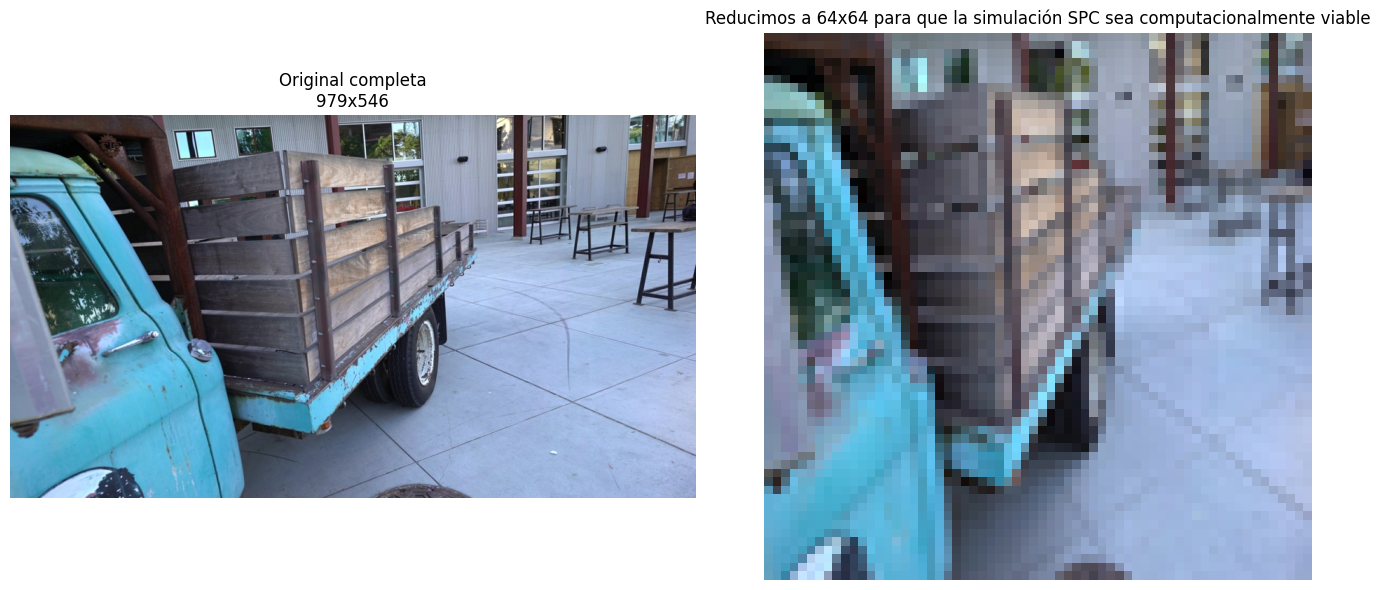

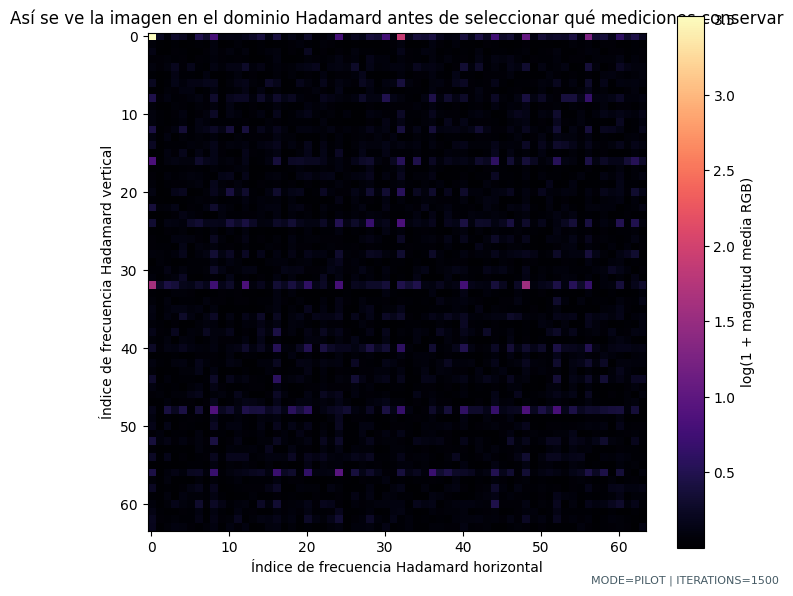

In [83]:
reference_working = load_image(REFERENCE_FILE)
reference_coefficients = np.stack([
    H @ reference_working[..., c] @ H.T
    for c in range(reference_working.shape[-1])
], axis=-1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(reference_original)
axes[0].set_title(f'Original completa\n{reference_original.shape[1]}x{reference_original.shape[0]}')
axes[0].axis('off')
axes[1].imshow(reference_working)
axes[1].set_title(
    f'Reducimos a {IMAGE_SIZE[0]}x{IMAGE_SIZE[1]} para que la simulación SPC sea computacionalmente viable'
)
axes[1].axis('off')
plt.tight_layout()

coefficient_magnitude = np.log1p(np.mean(np.abs(reference_coefficients), axis=-1))
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(coefficient_magnitude, cmap='magma')
ax.set_title('Así se ve la imagen en el dominio Hadamard antes de seleccionar qué mediciones conservar')
ax.set_xlabel('Índice de frecuencia Hadamard horizontal')
ax.set_ylabel('Índice de frecuencia Hadamard vertical')
fig.colorbar(im, ax=ax, label='log(1 + magnitud media RGB)')
plt.tight_layout()

if 'fig' in globals() and 'MODE' in globals():
    fig.text(0.99, 0.01, f'MODE={MODE} | ITERATIONS={ITERATIONS}', ha='right', va='bottom', fontsize=8, color='#455A64')


## 5. Evaluar el compromiso compresión–calidad

**Puente narrativo:** ahora seleccionaremos solo una fracción de los coeficientes Hadamard y reconstruiremos la misma vista de referencia. Compararemos cuánto detalle sobrevive al reducir las mediciones.

Comparamos varias cantidades de mediciones sobre una vista. PSNR mide error de reconstrucción y SSIM compara estructura visual; ambas métricas se calculan contra la imagen RGB original redimensionada.

,ratio_mediciones,numero_mediciones,psnr_db,ssim
0,0.05,205,18.622581,0.488063
1,0.10,410,20.082250,0.635773
2,0.25,1024,22.856064,0.815980
3,0.50,2048,27.114800,0.917411


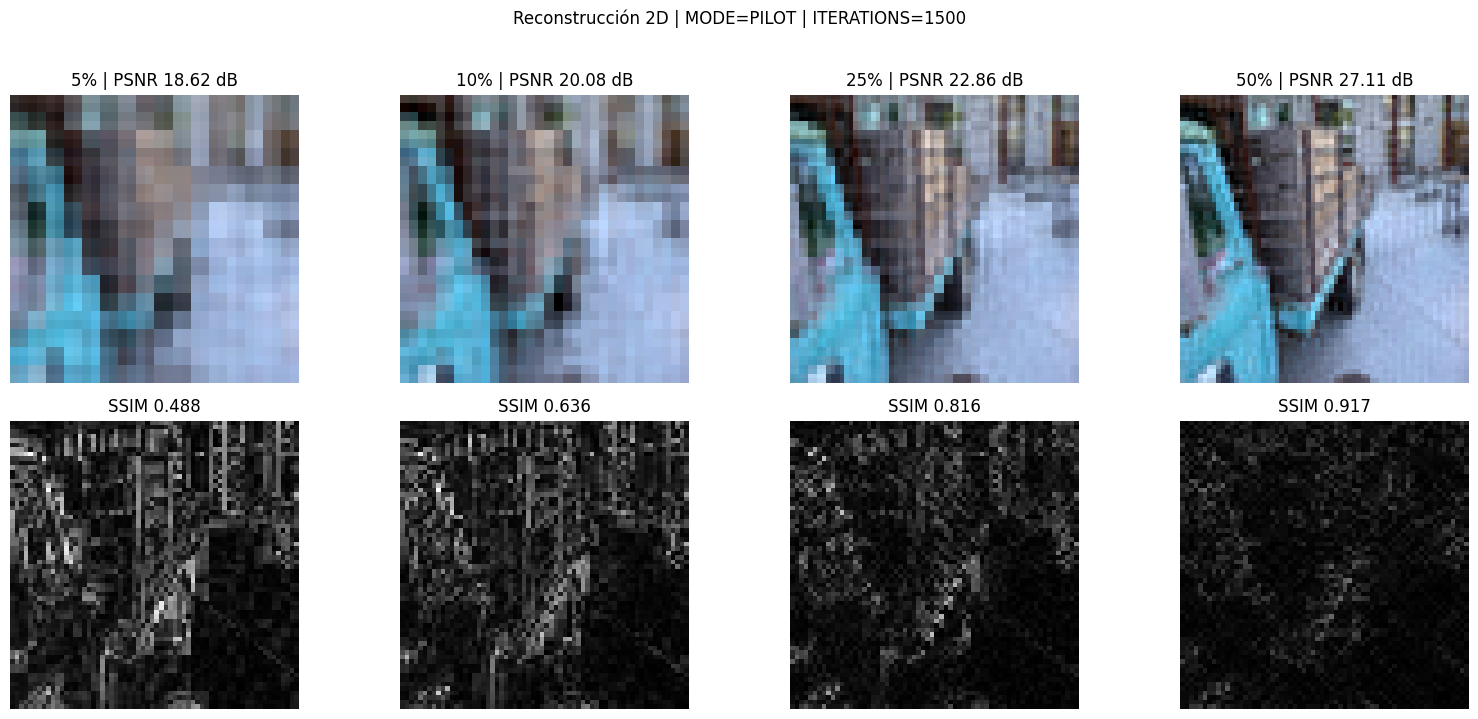

In [84]:
def compute_metrics(reference: np.ndarray, reconstruction: np.ndarray):
    """Única definición 2D: RGB [0,1], misma resolución y data_range=1."""
    reference = np.asarray(reference, dtype=np.float32)
    reconstruction = np.asarray(reconstruction, dtype=np.float32)
    if reference.shape != reconstruction.shape:
        raise ValueError(f'compute_metrics exige la misma forma; recibió {reference.shape} y {reconstruction.shape}.')
    reference = np.clip(reference, 0.0, 1.0)
    reconstruction = np.clip(reconstruction, 0.0, 1.0)
    return (
        float(peak_signal_noise_ratio(reference, reconstruction, data_range=1.0)),
        float(structural_similarity(reference, reconstruction, channel_axis=-1, data_range=1.0)),
    )

reference = load_image(REFERENCE_FILE)
evaluations = []
fig, axes = plt.subplots(2, len(COMPRESSION_RATIOS), figsize=(16, 7))
axes = np.atleast_2d(axes)
for col, ratio in enumerate(COMPRESSION_RATIOS):
    reconstruction, measurements = reconstruct_view(reference, ratio)
    psnr, ssim = compute_metrics(reference, reconstruction)
    evaluations.append({'ratio_mediciones': ratio, 'numero_mediciones': len(measurements), 'psnr_db': psnr, 'ssim': ssim})
    axes[0, col].imshow(reconstruction); axes[0, col].set_title(f'{ratio:.0%} | PSNR {psnr:.2f} dB'); axes[0, col].axis('off')
    axes[1, col].imshow(np.abs(reference - reconstruction).mean(axis=-1), vmin=0, vmax=0.5); axes[1, col].set_title(f'SSIM {ssim:.3f}'); axes[1, col].axis('off')
plt.suptitle(f'Reconstrucción 2D | MODE={MODE} | ITERATIONS={ITERATIONS}', y=1.02)
plt.tight_layout()
evaluation_table = pd.DataFrame(evaluations)
display(evaluation_table)

### Qué conserva cada nivel de compresión

Para la misma vista de referencia, la fila superior muestra la reconstrucción y la fila inferior superpone en cian los coeficientes Hadamard conservados sobre el mapa completo.

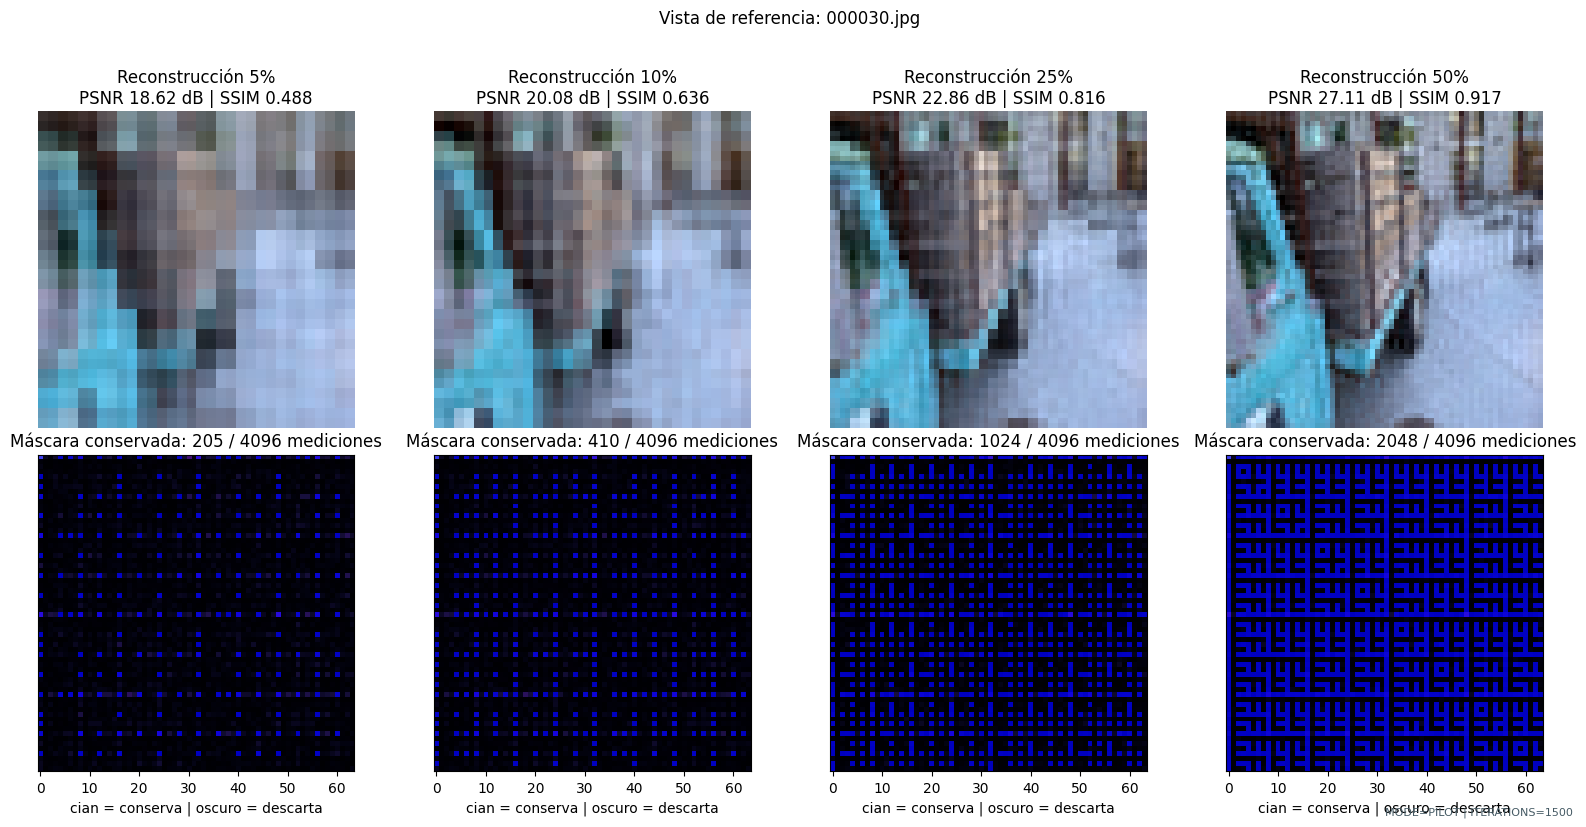

In [85]:
fig, axes = plt.subplots(2, len(COMPRESSION_RATIOS), figsize=(4 * len(COMPRESSION_RATIOS), 8))
for col, ratio in enumerate(COMPRESSION_RATIOS):
    reconstruction, measurements = reconstruct_view(reference_working, ratio)
    selected = HADAMARD_ORDER[:len(measurements)]
    selected_mask = np.zeros(reference_coefficients.shape[:2], dtype=bool)
    for i, j in selected:
        selected_mask[i, j] = True

    psnr, ssim = compute_metrics(reference_working, reconstruction)
    axes[0, col].imshow(reconstruction)
    axes[0, col].set_title(f'Reconstrucción {ratio:.0%}\nPSNR {psnr:.2f} dB | SSIM {ssim:.3f}')
    axes[0, col].axis('off')

    axes[1, col].imshow(coefficient_magnitude, cmap='magma')
    axes[1, col].imshow(np.ma.masked_where(~selected_mask, selected_mask), cmap='winter', alpha=0.75, interpolation='nearest')
    axes[1, col].set_title(f'Máscara conservada: {len(selected)} / {len(HADAMARD_ORDER)} mediciones')
    axes[1, col].set_xlabel('cian = conserva | oscuro = descarta')
    axes[1, col].set_yticks([])
plt.suptitle(f'Vista de referencia: {REFERENCE_FILE.name}', y=1.02)
plt.tight_layout()

if 'fig' in globals() and 'MODE' in globals():
    fig.text(0.99, 0.01, f'MODE={MODE} | ITERATIONS={ITERATIONS}', ha='right', va='bottom', fontsize=8, color='#455A64')


## 6. Reconstruir las vistas y preparar entradas para 3DGS

\`original\` conserva las imágenes RGB sin procesar. \`resized\` reduce a \`IMAGE_SIZE\` y reescala sin Hadamard, separando el efecto de resolución. Las carpetas \`spc_XXX\` aplican Hadamard y también conservan el tamaño original exigido por las poses COLMAP.

En \`PILOT\` se entrenan \`original\` y \`spc_025\`. En \`FULL\` se entrenan \`original\`, \`resized\` y todos los ratios definidos en \`COMPRESSION_RATIOS\`.

In [86]:
def ratio_tag(ratio: float):
    return f'{ratio:.2f}'.replace('.', '')

def prepare_scene_folder(folder: Path):
    folder.mkdir(parents=True, exist_ok=True)
    images_dir = folder / 'images'
    if images_dir.exists():
        shutil.rmtree(images_dir)
    images_dir.mkdir(parents=True, exist_ok=True)
    for metadata_name in ['sparse', 'database.db', 'poses_bounds.npy', 'transforms.json']:
        source = LOCAL_SCENE / metadata_name
        destination = folder / metadata_name
        if source.is_dir():
            shutil.copytree(source, destination, dirs_exist_ok=True)
        elif source.is_file():
            shutil.copy2(source, destination)
    return images_dir

BASELINE_SCENE = RUN_ROOT / 'images_original'
RESIZED_SCENE = RUN_ROOT / 'images_resized'
SPC_SCENES = {ratio: RUN_ROOT / f'images_spc_{ratio_tag(ratio)}' for ratio in COMPRESSION_RATIOS}
if MODE == 'PILOT':
    if 0.25 not in SPC_SCENES:
        raise ValueError('PILOT requiere 0.25 dentro de COMPRESSION_RATIOS.')
    SCENE_FOLDERS = {'original': BASELINE_SCENE, 'spc_025': SPC_SCENES[0.25]}
else:
    SCENE_FOLDERS = {'original': BASELINE_SCENE, 'resized': RESIZED_SCENE,
                     **{f'spc_{ratio_tag(r)}': folder for r, folder in SPC_SCENES.items()}}
SCENE_IMAGES = {name: prepare_scene_folder(folder) for name, folder in SCENE_FOLDERS.items()}

# Se activa antes de generar las vistas, corrigiendo el registro de tiempos cero.
import time
_OE3_ORIGINAL_RECONSTRUCT_VIEW = reconstruct_view
_OE3_TIMINGS = {float(ratio): [] for ratio in COMPRESSION_RATIOS}
def _reconstruct_view_timed(image, ratio):
    start = time.perf_counter()
    result = _OE3_ORIGINAL_RECONSTRUCT_VIEW(image, ratio)
    _OE3_TIMINGS.setdefault(float(ratio), []).append(time.perf_counter() - start)
    return result
reconstruct_view = _reconstruct_view_timed

rows_by_scene = {name: [] for name in SCENE_FOLDERS}
manifest_by_scene = {name: [] for name in SCENE_FOLDERS}
if len({path.name for path in image_files}) != len(image_files):
    raise ValueError('Hay nombres de archivo duplicados; no es seguro mapear vistas por nombre.')

try:
    for path in tqdm(image_files, desc=f'Procesando vistas | {MODE}'):
        working = load_image(path)
        original_full = load_original_image(path)
        original_size = (original_full.shape[1], original_full.shape[0])
        relative_name = str(path.relative_to(LOCAL_SCENE))
        # Guardamos la imagen con el nombre exacto de su pose COLMAP.
        output_name = pose_name_by_path[path]

        if 'original' in SCENE_FOLDERS:
            output = SCENE_IMAGES['original'] / output_name
            shutil.copy2(path, output)
            psnr, ssim = compute_metrics(original_full, original_full)
            rows_by_scene['original'].append({'archivo_original': relative_name, 'archivo_reconstruido': str(output), 'nivel': 'original', 'ratio_mediciones': 1.0, 'numero_mediciones': 0, 'psnr_db': psnr, 'ssim': ssim, 'referencia_2d': 'original'})
            manifest_by_scene['original'].append({'image_name': output.name, 'entrada_3d': str(output), 'original_path': str(path), 'source_relative': relative_name})

        if 'resized' in SCENE_FOLDERS:
            output = SCENE_IMAGES['resized'] / output_name
            resized_full = save_at_original_resolution(working, path, output)
            psnr, ssim = compute_metrics(original_full, resized_full)
            rows_by_scene['resized'].append({'archivo_original': relative_name, 'archivo_reconstruido': str(output), 'nivel': 'resized', 'ratio_mediciones': 0.0, 'numero_mediciones': 0, 'psnr_db': psnr, 'ssim': ssim, 'referencia_2d': 'original'})
            manifest_by_scene['resized'].append({'image_name': output.name, 'entrada_3d': str(output), 'original_path': str(path), 'source_relative': relative_name})

        for ratio in COMPRESSION_RATIOS:
            scene_name = f'spc_{ratio_tag(ratio)}'
            if scene_name not in SCENE_FOLDERS:
                continue
            reconstruction, measurements = reconstruct_view(working, ratio)
            output = SCENE_IMAGES[scene_name] / output_name
            reconstruction_full = save_at_original_resolution(reconstruction, path, output)
            psnr, ssim = compute_metrics(original_full, reconstruction_full)
            rows_by_scene[scene_name].append({'archivo_original': relative_name, 'archivo_reconstruido': str(output), 'nivel': scene_name, 'ratio_mediciones': ratio, 'numero_mediciones': len(measurements), 'psnr_db': psnr, 'ssim': ssim, 'referencia_2d': 'original'})
            manifest_by_scene[scene_name].append({'image_name': output.name, 'entrada_3d': str(output), 'original_path': str(path), 'source_relative': relative_name})
finally:
    reconstruct_view = _OE3_ORIGINAL_RECONSTRUCT_VIEW
expected_colmap_names = {pose_name_by_path[path] for path in image_files}
for scene_name, images_folder in SCENE_IMAGES.items():
    generated_names = {path.name for path in images_folder.iterdir() if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS}
    if generated_names != expected_colmap_names:
        raise RuntimeError(f'{scene_name}: nombres generados no coinciden con COLMAP. Esperados={sorted(expected_colmap_names)[:5]}..., recibidos={sorted(generated_names)[:5]}...')
    print(f'{scene_name}: nombres COLMAP verificados ({len(generated_names)} imágenes), ejemplo={sorted(generated_names)[:3]}')

def save_metrics_with_average(rows, folder: Path):
    per_image = pd.DataFrame(rows)
    average_row = {column: '' for column in per_image.columns}
    average_row.update({'archivo_original': '__average__', 'nivel': per_image['nivel'].iloc[0], 'ratio_mediciones': per_image['ratio_mediciones'].iloc[0], 'numero_mediciones': per_image['numero_mediciones'].mean(), 'psnr_db': per_image['psnr_db'].mean(), 'ssim': per_image['ssim'].mean(), 'referencia_2d': 'original'})
    metrics = pd.concat([per_image, pd.DataFrame([average_row])], ignore_index=True)
    metrics.to_csv(folder / 'metrics.csv', index=False)
    return metrics

metrics_by_scene = {name: save_metrics_with_average(rows, SCENE_FOLDERS[name]) for name, rows in rows_by_scene.items()}
summary = []
for name, metrics in metrics_by_scene.items():
    average = metrics[metrics['archivo_original'] == '__average__'].iloc[0]
    summary.append({'escena': name, 'carpeta': str(SCENE_FOLDERS[name]), 'modo': MODE, 'iteraciones': ITERATIONS, 'numero_vistas': len(metrics) - 1, 'psnr_db_promedio': average['psnr_db'], 'ssim_promedio': average['ssim'], 'referencia_2d': 'original'})
summary_df = pd.DataFrame(summary)
summary_df.to_csv(RUN_ROOT / 'summary_all_levels.csv', index=False)
for name, manifest in manifest_by_scene.items():
    pd.DataFrame(manifest).to_csv(SCENE_FOLDERS[name] / 'image_manifest.csv', index=False)
print(f'Vistas procesadas por nivel: {len(image_files)}')
display(summary_df)
for name, folder in SCENE_FOLDERS.items():
    print(f'{name:12s} -> {folder} | metrics.csv: {folder / "metrics.csv"}')

Procesando vistas | PILOT:   0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


original: nombres COLMAP verificados (30 imágenes), ejemplo=['01.jpg', '04.jpg', '08.jpg']
spc_025: nombres COLMAP verificados (30 imágenes), ejemplo=['01.jpg', '04.jpg', '08.jpg']
Vistas procesadas por nivel: 30


,escena,carpeta,modo,iteraciones,numero_vistas,psnr_db_promedio,ssim_promedio,referencia_2d
0,original,/content/drive/MyDrive/inf479/proyecto_final_r...,PILOT,1500,30,inf,1.00000,original
1,spc_025,/content/drive/MyDrive/inf479/proyecto_final_r...,PILOT,1500,30,18.540565,0.45738,original


original     -> /content/drive/MyDrive/inf479/proyecto_final_resultados/pilot_iter1500/images_original | metrics.csv: /content/drive/MyDrive/inf479/proyecto_final_resultados/pilot_iter1500/images_original/metrics.csv
spc_025      -> /content/drive/MyDrive/inf479/proyecto_final_resultados/pilot_iter1500/images_spc_025 | metrics.csv: /content/drive/MyDrive/inf479/proyecto_final_resultados/pilot_iter1500/images_spc_025/metrics.csv


### Comparación ilustrativa: Hadamard frente a máscaras binarias aleatorias

Como control de OE2, repetimos la reconstrucción de la vista de referencia con patrones aleatorios binarios $\{-1,+1\}$. Usamos retroproyección normalizada, suficiente para una comparación cualitativa; no se generan carpetas 3DGS con este método.

,metodo,ratio_mediciones,psnr_db,ssim
0,Hadamard,0.10,20.082250,0.635773
1,Aleatoria +/-1,0.10,6.145576,0.038079
2,Hadamard,0.25,22.856064,0.815980
3,Aleatoria +/-1,0.25,6.714056,0.051997


Interpretación: Hadamard ofrece una base ortogonal y ordenable por frecuencia; esta comparación muestra el costo de sustituirla por patrones aleatorios.


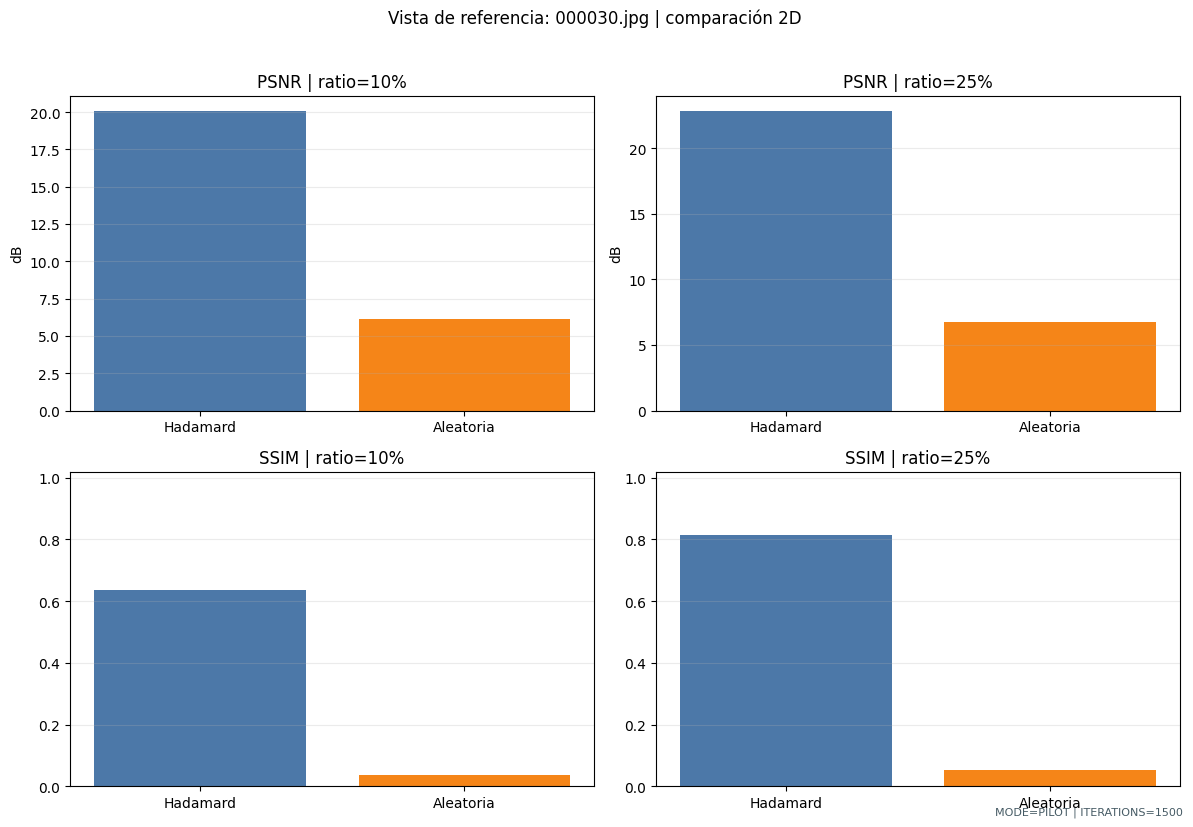

In [87]:
RANDOM_COMPARISON_RATIOS = list(dict.fromkeys([
    ratio for ratio in [0.10, 0.25] if ratio in COMPRESSION_RATIOS
]))
if not RANDOM_COMPARISON_RATIOS:
    RANDOM_COMPARISON_RATIOS = COMPRESSION_RATIOS[:min(2, len(COMPRESSION_RATIOS))]

def random_binary_reconstruct(image: np.ndarray, ratio: float, seed: int = 449):
    """Reconstruye por retroproyección con máscaras aleatorias +/-1."""
    height, width, channels = image.shape
    n_pixels = height * width
    n_measurements = max(1, int(round(float(ratio) * n_pixels)))
    rng = np.random.default_rng(seed + int(round(float(ratio) * 1000)))
    reconstruction_accumulator = np.zeros_like(image, dtype=np.float32)
    # Procesamos por bloques para que el control siga siendo viable también con 128x128.
    chunk_size = 256
    for start in range(0, n_measurements, chunk_size):
        count = min(chunk_size, n_measurements - start)
        masks = rng.choice(
            np.array([-1.0, 1.0], dtype=np.float32),
            size=(count, height, width)
        )
        measurements = np.einsum('mij,ijc->mc', masks, image, optimize=True)
        reconstruction_accumulator += np.einsum(
            'mij,mc->ijc', masks, measurements, optimize=True
        )
    reconstruction = reconstruction_accumulator / n_measurements
    return np.clip(reconstruction, 0.0, 1.0), n_measurements, None

random_rows = []
fig, axes = plt.subplots(2, len(RANDOM_COMPARISON_RATIOS), figsize=(6 * len(RANDOM_COMPARISON_RATIOS), 8))
axes = np.atleast_2d(axes)
for col, ratio in enumerate(RANDOM_COMPARISON_RATIOS):
    hadamard_reconstruction, hadamard_measurements = reconstruct_view(reference_working, ratio)
    random_reconstruction, n_random, _ = random_binary_reconstruct(reference_working, ratio)
    hadamard_psnr, hadamard_ssim = compute_metrics(reference_working, hadamard_reconstruction)
    random_psnr, random_ssim = compute_metrics(reference_working, random_reconstruction)
    random_rows.extend([
        {'metodo': 'Hadamard', 'ratio_mediciones': ratio, 'psnr_db': hadamard_psnr, 'ssim': hadamard_ssim},
        {'metodo': 'Aleatoria +/-1', 'ratio_mediciones': ratio, 'psnr_db': random_psnr, 'ssim': random_ssim},
    ])
    axes[0, col].bar(['Hadamard', 'Aleatoria'], [hadamard_psnr, random_psnr], color=['#4C78A8', '#F58518'])
    axes[0, col].set_title(f'PSNR | ratio={ratio:.0%}')
    axes[0, col].set_ylabel('dB')
    axes[0, col].grid(axis='y', alpha=0.25)
    axes[1, col].bar(['Hadamard', 'Aleatoria'], [hadamard_ssim, random_ssim], color=['#4C78A8', '#F58518'])
    axes[1, col].set_title(f'SSIM | ratio={ratio:.0%}')
    axes[1, col].set_ylim(0, 1.02)
    axes[1, col].grid(axis='y', alpha=0.25)
fig.suptitle(f'Vista de referencia: {REFERENCE_FILE.name} | comparación 2D', y=1.02)
plt.tight_layout()
random_comparison_df = pd.DataFrame(random_rows)
display(random_comparison_df)
print('Interpretación: Hadamard ofrece una base ortogonal y ordenable por frecuencia; esta comparación muestra el costo de sustituirla por patrones aleatorios.')

if 'fig' in globals() and 'MODE' in globals():
    fig.text(0.99, 0.01, f'MODE={MODE} | ITERATIONS={ITERATIONS}', ha='right', va='bottom', fontsize=8, color='#455A64')


### Dispersión entre vistas

El promedio puede ocultar que algunas cámaras sean más difíciles de reconstruir. Por eso calculamos la desviación estándar de PSNR y SSIM sobre todas las vistas para cada ratio y la mostramos como barras de error.

### Métricas 2D unificadas e instrumentación

La dispersión y el resumen usan la misma función compute_metrics, siempre contra la imagen original y después de reescalar a la resolución original. La diferencia histórica provenía de comparar IMAGE_SIZE contra IMAGE_SIZE en un caso y resolución original contra imagen reescalada en el otro.

Calculando dispersión 2D entre vistas:   0%|          | 0/30 [00:00<?, ?it/s]

,ratio_mediciones,psnr_db_promedio,psnr_db_std,ssim_promedio,ssim_std,numero_vistas
0,0.05,16.481450,0.633264,0.429487,0.049391,30
1,0.10,17.300405,0.608471,0.433986,0.049791,30
2,0.25,18.540565,0.615712,0.457380,0.048094,30
3,0.50,19.697632,0.588473,0.493655,0.044678,30


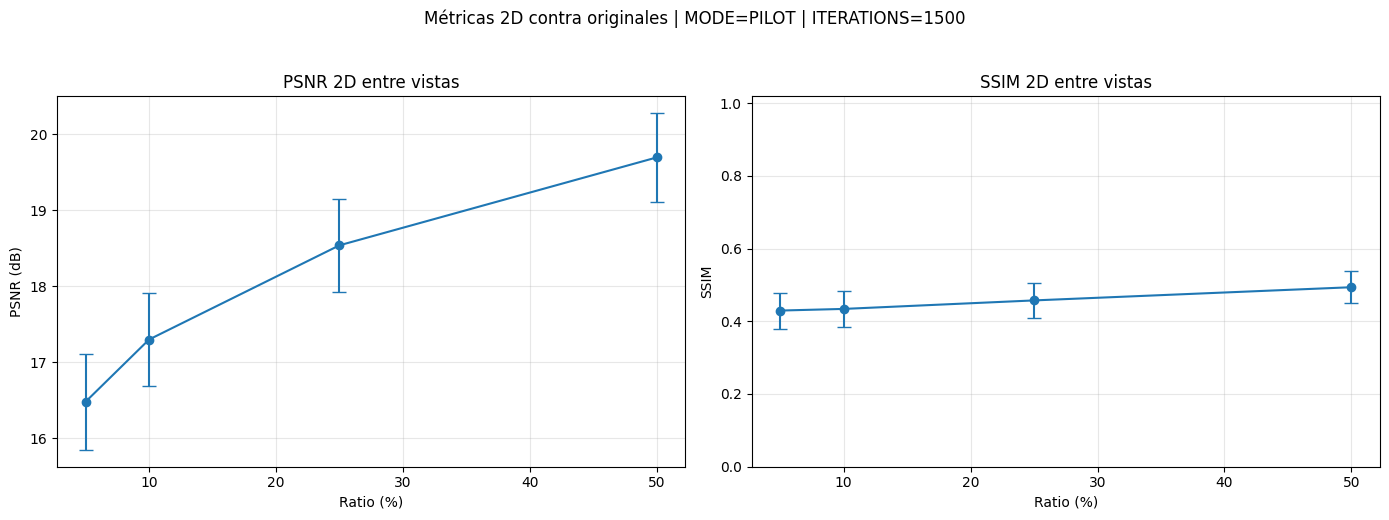

In [88]:
dispersion_rows = []
for view_file in tqdm(image_files, desc='Calculando dispersión 2D entre vistas'):
    original_full = load_original_image(view_file)
    original_size = (original_full.shape[1], original_full.shape[0])
    working = load_image(view_file)
    for ratio in COMPRESSION_RATIOS:
        reconstruction, measurements = reconstruct_view(working, ratio)
        reconstruction_full = resize_to_original_resolution(reconstruction, original_size)
        psnr, ssim = compute_metrics(original_full, reconstruction_full)
        dispersion_rows.append({'archivo': view_file.name, 'ratio_mediciones': ratio, 'psnr_db': psnr, 'ssim': ssim, 'numero_mediciones': len(measurements), 'referencia': 'original'})
dispersion_per_view_df = pd.DataFrame(dispersion_rows)
dispersion_summary_df = (dispersion_per_view_df.groupby('ratio_mediciones')
                         .agg(psnr_db_promedio=('psnr_db', 'mean'), psnr_db_std=('psnr_db', 'std'), ssim_promedio=('ssim', 'mean'), ssim_std=('ssim', 'std'), numero_vistas=('archivo', 'nunique'))
                         .reset_index().sort_values('ratio_mediciones'))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = dispersion_summary_df['ratio_mediciones'] * 100
axes[0].errorbar(x, dispersion_summary_df['psnr_db_promedio'], yerr=dispersion_summary_df['psnr_db_std'], fmt='o-', capsize=5)
axes[0].set(xlabel='Ratio (%)', ylabel='PSNR (dB)', title='PSNR 2D entre vistas'); axes[0].grid(True, alpha=0.3)
axes[1].errorbar(x, dispersion_summary_df['ssim_promedio'], yerr=dispersion_summary_df['ssim_std'], fmt='o-', capsize=5)
axes[1].set(xlabel='Ratio (%)', ylabel='SSIM', title='SSIM 2D entre vistas', ylim=(0, 1.02)); axes[1].grid(True, alpha=0.3)
fig.suptitle(f'Métricas 2D contra originales | MODE={MODE} | ITERATIONS={ITERATIONS}', y=1.03)
plt.tight_layout()
dispersion_summary_df.to_csv(RUN_ROOT / 'dispersion_oe2.csv', index=False)
display(dispersion_summary_df)

### Instrumentación de tiempo para OE3

reconstruct_view se envolvió antes del bucle de generación. La celda siguiente solo consolida los tiempos y no vuelve a envolver la función.

In [89]:
SPC_TIMING_ROWS = []
for ratio, samples in _OE3_TIMINGS.items():
    SPC_TIMING_ROWS.append({'ratio_mediciones': ratio, 'vistas_mediadas': len(samples), 'tiempo_spc_total_s': float(np.sum(samples)) if samples else 0.0, 'tiempo_spc_promedio_por_vista_s': float(np.mean(samples)) if samples else np.nan})
SPC_TIMING_SUMMARY = pd.DataFrame(SPC_TIMING_ROWS).sort_values('ratio_mediciones')
SPC_TIMING_SUMMARY.to_csv(RUN_ROOT / 'tiempos_spc_por_ratio.csv', index=False)
display(SPC_TIMING_SUMMARY)

,ratio_mediciones,vistas_mediadas,tiempo_spc_total_s,tiempo_spc_promedio_por_vista_s
0,0.05,0,0.00000,NaN
1,0.10,0,0.00000,NaN
2,0.25,30,0.09471,0.003157
3,0.50,0,0.00000,NaN


In [90]:
print('Resumen temporal OE3 ya consolidado en:', RUN_ROOT / 'tiempos_spc_por_ratio.csv')
display(SPC_TIMING_SUMMARY)


Resumen temporal OE3 ya consolidado en: /content/drive/MyDrive/inf479/proyecto_final_resultados/pilot_iter1500/tiempos_spc_por_ratio.csv


,ratio_mediciones,vistas_mediadas,tiempo_spc_total_s,tiempo_spc_promedio_por_vista_s
0,0.05,0,0.00000,NaN
1,0.10,0,0.00000,NaN
2,0.25,30,0.09471,0.003157
3,0.50,0,0.00000,NaN


### Resolución final y compatibilidad con las poses

La reconstrucción se calculó en `IMAGE_SIZE`, pero 3DGS necesita que el archivo conserve las dimensiones usadas al calibrar `cameras.bin`. Aquí seguimos la vista de referencia después del reescalado LANCZOS.

Archivo guardado para esta vista: /content/drive/MyDrive/inf479/proyecto_final_resultados/pilot_iter1500/images_spc_025/images/000030.jpg


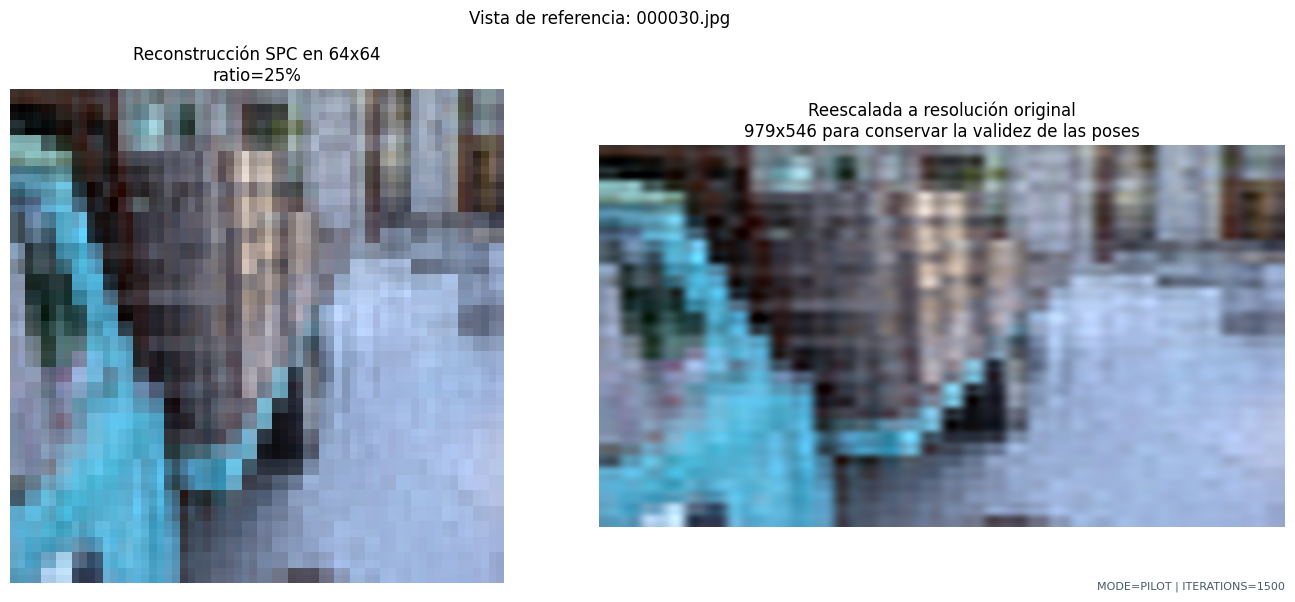

In [91]:
demo_ratio = DEMO_RATIO if DEMO_RATIO in COMPRESSION_RATIOS else COMPRESSION_RATIOS[0]
demo_scene_name = f'spc_{ratio_tag(demo_ratio)}'
demo_reconstruction_working, _ = reconstruct_view(reference_working, demo_ratio)
demo_reconstruction_full = resize_to_original_resolution(
    demo_reconstruction_working, REFERENCE_ORIGINAL_SIZE
)
saved_reference_path = SCENE_IMAGES[demo_scene_name] / REFERENCE_FILE.name
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(demo_reconstruction_working)
axes[0].set_title(f'Reconstrucción SPC en {IMAGE_SIZE[0]}x{IMAGE_SIZE[1]}\nratio={demo_ratio:.0%}')
axes[0].axis('off')
axes[1].imshow(demo_reconstruction_full)
axes[1].set_title(
    f'Reescalada a resolución original\n{REFERENCE_ORIGINAL_SIZE[0]}x{REFERENCE_ORIGINAL_SIZE[1]} para conservar la validez de las poses'
)
axes[1].axis('off')
fig.suptitle(f'Vista de referencia: {REFERENCE_FILE.name}')
plt.tight_layout()
print('Archivo guardado para esta vista:', saved_reference_path)

if 'fig' in globals() and 'MODE' in globals():
    fig.text(0.99, 0.01, f'MODE={MODE} | ITERATIONS={ITERATIONS}', ha='right', va='bottom', fontsize=8, color='#455A64')


original    : 30 imágenes con tamaño original conservado
spc_025     : 30 imágenes con tamaño original conservado


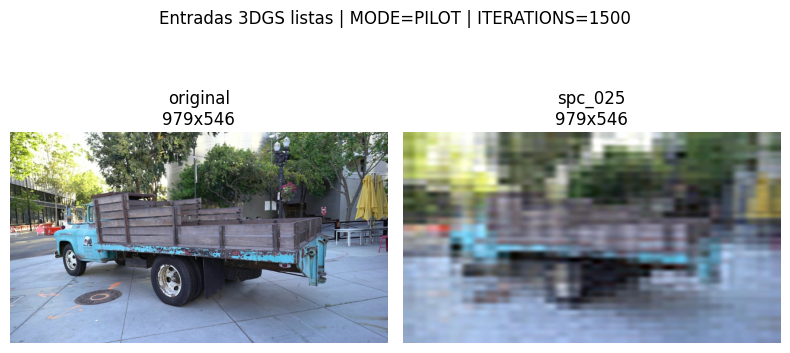

In [92]:
# Todas las escenas seleccionadas deben contener las mismas vistas y conservar su tamaño original.
for name, folder in SCENE_IMAGES.items():
    saved_images = sorted(p for p in folder.glob('*') if p.suffix.lower() in IMAGE_EXTENSIONS)
    if len(saved_images) != len(image_files):
        raise RuntimeError(f'{name}: se esperaban {len(image_files)} imágenes y hay {len(saved_images)}.')
    for saved, source in zip(saved_images, sorted(image_files, key=lambda p: p.name)):
        with Image.open(saved) as generated, Image.open(source) as original:
            if generated.size != original.size:
                raise RuntimeError(f'{name}/{saved.name}: {generated.size} != {original.size}.')
    print(f'{name:12s}: {len(saved_images)} imágenes con tamaño original conservado')
fig, axes = plt.subplots(1, len(SCENE_FOLDERS), figsize=(4 * len(SCENE_FOLDERS), 4))
axes = np.atleast_1d(axes)
for ax, (name, folder) in zip(axes, SCENE_FOLDERS.items()):
    saved_images = sorted((folder / 'images').glob('*'))
    with Image.open(saved_images[0]) as preview_image:
        ax.imshow(preview_image); ax.set_title(f'{name}\n{preview_image.size[0]}x{preview_image.size[1]}')
    ax.axis('off')
fig.suptitle(f'Entradas 3DGS listas | MODE={MODE} | ITERATIONS={ITERATIONS}', y=1.03)
plt.tight_layout()

## OE4 — Entrenamiento y evaluación 3D

La preparación del entorno sigue el flujo validado en gaussian_splatting_colab.ipynb: clona camenduru/gaussian-splatting con submódulos, diagnostica GPU/CUDA, aplica parches idempotentes de cabeceras, fija la arquitectura CUDA de la GPU y compila las extensiones con --no-build-isolation. La celda verifica las importaciones de diff-gaussian-rasterization y simple-knn antes de lanzar train.py.

Se usa \`--eval\`, \`--test_iterations ITERATIONS\`, \`--save_iterations ITERATIONS\` y una resolución controlada (`256` en PILOT, `512` en FULL). Las imágenes fuente se mantienen en CPU (`--data_device cpu`) para reducir el uso de VRAM de Colab. Render y métricas usan la misma iteración. \`FORCE_RETRAIN=True\` evita reutilizar modelos entrenados sin evaluación. Antes de entrenar se filtran las poses COLMAP para que \`sparse/0\` liste exactamente las imágenes seleccionadas; cualquier error de train, render o metrics detiene OE4 y deja el log en Drive.

### Registro temporal de OE4

Esta instrumentación registra la hora de inicio y fin de los comandos `train.py`, `render.py` y `metrics.py` por escena. También imprime el inicio y cierre de cada escena y permite conservar un resumen aunque el bucle se interrumpa después de algunas escenas.

In [93]:
from datetime import datetime
OE4_COMMAND_TIMINGS = []
OE4_SCENE_STARTS = {}
_OE4_ORIGINAL_SUBPROCESS_RUN = subprocess.run

def _oe4_scene_from_command(command):
    command = [str(part) for part in command]
    if '-m' in command:
        index = command.index('-m') + 1
        if index < len(command) and Path(command[index]).name.startswith('gs_'):
            return Path(command[index]).name[3:]
    return None

def _oe4_timed_subprocess_run(command, *args, **kwargs):
    command = [str(part) for part in command]
    phase = next((name for name in ['train.py', 'render.py', 'metrics.py'] if name in command), None)
    scene_name = _oe4_scene_from_command(command)
    if phase is None or scene_name is None:
        return _OE4_ORIGINAL_SUBPROCESS_RUN(command, *args, **kwargs)
    start = datetime.now(); started_perf = time.perf_counter()
    result = _OE4_ORIGINAL_SUBPROCESS_RUN(command, *args, **kwargs)
    end = datetime.now()
    OE4_COMMAND_TIMINGS.append({'escena': scene_name, 'etapa': phase, 'inicio': start.isoformat(timespec='seconds'), 'fin': end.isoformat(timespec='seconds'), 'duracion_s': time.perf_counter() - started_perf, 'estado': 'ok' if result.returncode == 0 else 'error'})
    return result

subprocess.run = _oe4_timed_subprocess_run
print('Registro temporal OE4 activo.')

Registro temporal OE4 activo.


In [94]:
# =========================
# Configuración y ejecución 3DGS
# =========================
import os
import struct
# Esta variante es la que se validó en gaussian_splatting_colab.ipynb.
# camenduru mantiene el árbol con submódulos listo para compilar en Colab.
GS_REPO_URL = 'https://github.com/camenduru/gaussian-splatting'
GS_REPO = Path('/content/gaussian-splatting')
# La entrada fue reescalada al tamaño original para conservar compatibilidad con COLMAP,
# pero entrenar a esa resolución puede agotar la VRAM. 3DGS ajusta las cámaras al
# reducir la resolución durante la carga. Usa 256 para el piloto y 512 para FULL si alcanza.
GS_RESOLUTION = 256 if MODE == 'PILOT' else 512
# La T4 tiene 16 GB nominales (~14.5 GB visibles en Colab). Dejamos las
# imágenes en CPU y movemos solo lo necesario al GPU durante el entrenamiento.
GS_DATA_DEVICE = 'cpu'
GS_OUTPUTS_ROOT = RUN_ROOT / 'gs_outputs'
LOG_ROOT = RUN_ROOT / 'logs'
GS_OUTPUTS_ROOT.mkdir(parents=True, exist_ok=True)
LOG_ROOT.mkdir(parents=True, exist_ok=True)

def run_gs_command(command, cwd=None, label='comando', log_path=None):
    print(f'\n[{label}]')
    print(' '.join(str(part) for part in command))
    try:
        completed = subprocess.run(command, cwd=cwd, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, check=False)
    except Exception as error:
        print(f'No se pudo iniciar el comando: {error}')
        return False
    output = completed.stdout or ''
    if log_path is not None:
        Path(log_path).write_text(output, encoding='utf-8')
    if output:
        print(output[-12000:])
    if completed.returncode != 0:
        print(f'El comando terminó con código {completed.returncode}.')
        return False
    return True

def _diagnose_3dgs_environment():
    """Imprime el entorno antes de compilar las extensiones CUDA."""
    print('--- Diagnóstico de GPU/CUDA ---')
    run_gs_command(['nvidia-smi'], label='nvidia-smi')
    run_gs_command(['nvcc', '--version'], label='nvcc --version')
    try:
        import torch
        print('PyTorch:', torch.__version__)
        print('CUDA de PyTorch:', torch.version.cuda or 'no disponible')
        print('CUDA disponible:', torch.cuda.is_available())
        if torch.cuda.is_available():
            print('Capacidad compute:', torch.cuda.get_device_capability())
    except Exception as error:
        print(f'No se pudo consultar PyTorch: {error!r}')

def _patch_3dgs_sources():
    """Aplica los parches de cabecera requeridos por algunos runtimes Colab."""
    rasterizer_header = GS_REPO / 'submodules/diff-gaussian-rasterization/cuda_rasterizer/rasterizer_impl.h'
    simple_knn_source = GS_REPO / 'submodules/simple-knn/simple_knn.cu'
    if not rasterizer_header.exists() or not simple_knn_source.exists():
        raise FileNotFoundError('No se encontraron las fuentes de las extensiones CUDA.')
    header_text = rasterizer_header.read_text(encoding='utf-8')
    if '#include <cstdint>' not in header_text:
        header_text = header_text.replace('#pragma once', '#pragma once\n#include <cstdint>', 1)
        rasterizer_header.write_text(header_text, encoding='utf-8')
        print('Parche aplicado: <cstdint>')
    else:
        print('Parche <cstdint>: ya estaba aplicado.')
    knn_text = simple_knn_source.read_text(encoding='utf-8')
    if '#include <float.h>' not in knn_text:
        simple_knn_source.write_text('#include <float.h>\n' + knn_text, encoding='utf-8')
        print('Parche aplicado: <float.h>')
    else:
        print('Parche <float.h>: ya estaba aplicado.')

def prepare_gs_repository():
    _diagnose_3dgs_environment()
    if GS_REPO.exists() and (GS_REPO / '.git').exists():
        remote = subprocess.run(['git', '-C', str(GS_REPO), 'remote', 'get-url', 'origin'], text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, check=False).stdout.strip()
        if 'camenduru/gaussian-splatting' not in remote:
            legacy_repo = GS_REPO.with_name(GS_REPO.name + '-legacy')
            if legacy_repo.exists():
                raise RuntimeError(f'Ya existe un repositorio legado en {legacy_repo}; reinicia el runtime o elimínalo manualmente.')
            GS_REPO.rename(legacy_repo)
            print(f'Clon anterior conservado en {legacy_repo}; se preparará el repositorio camenduru.')
    if not GS_REPO.exists():
        if not run_gs_command(['git', 'clone', '--recursive', GS_REPO_URL, str(GS_REPO)], label='clonando Gaussian Splatting (camenduru)'):
            return False
    if not run_gs_command(['git', 'submodule', 'update', '--init', '--recursive'], cwd=GS_REPO, label='inicializando submódulos'):
        return False
    _patch_3dgs_sources()

    try:
        import torch
        if not torch.cuda.is_available():
            print('3DGS requiere una GPU CUDA activa; torch.cuda.is_available() devolvió False.')
            return False
        capability = torch.cuda.get_device_capability()
        os.environ['TORCH_CUDA_ARCH_LIST'] = f'{capability[0]}.{capability[1]}'
        print('TORCH_CUDA_ARCH_LIST =', os.environ['TORCH_CUDA_ARCH_LIST'])
    except Exception as error:
        print(f'No se pudo configurar la arquitectura CUDA: {error!r}')
        return False

    # Usa el torch/CUDA del runtime de Colab durante la compilación.
    install_commands = [
        [sys.executable, '-m', 'pip', 'install', 'plyfile'],
        [sys.executable, '-m', 'pip', 'install', '--no-build-isolation', str(GS_REPO / 'submodules/diff-gaussian-rasterization')],
        [sys.executable, '-m', 'pip', 'install', '--no-build-isolation', str(GS_REPO / 'submodules/simple-knn')],
    ]
    for command in install_commands:
        if not run_gs_command(command, label=f'instalando {command[-1]}'):
            return False

    try:
        from diff_gaussian_rasterization import GaussianRasterizationSettings, GaussianRasterizer
        from simple_knn._C import distCUDA2
        print('Extensiones CUDA de 3DGS: importación OK.')
    except Exception as error:
        print(f'Las extensiones de 3DGS no se pueden importar: {error!r}')
        print('La compilación terminó, pero el runtime no puede cargar las extensiones.')
        return False
    return True

def read_colmap_images_binary(path):
    records = []
    with open(path, 'rb') as file:
        count = struct.unpack('<Q', file.read(8))[0]
        for _ in range(count):
            image_id, *values = struct.unpack('<Q7di', file.read(68))
            name_bytes = bytearray()
            while True:
                byte = file.read(1)
                if byte == b'\x00':
                    break
                name_bytes.extend(byte)
            n_points = struct.unpack('<Q', file.read(8))[0]
            records.append((image_id, values[:4], values[4:7], int(values[7]), name_bytes.decode('utf-8'), n_points, file.read(24 * n_points)))
    return records

def write_colmap_images_binary(path, records):
    with open(path, 'wb') as file:
        file.write(struct.pack('<Q', len(records)))
        for image_id, qvec, tvec, camera_id, name, n_points, points_bytes in records:
            file.write(struct.pack('<Q7di', image_id, *qvec, *tvec, camera_id))
            file.write(name.encode('utf-8') + b'\x00')
            file.write(struct.pack('<Q', n_points)); file.write(points_bytes)

def filter_sparse_to_available_images(scene_folder):
    """Alinea images/ con COLMAP priorizando nombres exactos y fallback numérico inequívoco."""
    sparse = scene_folder / 'sparse' / '0'
    images_dir = scene_folder / 'images'
    available_paths = sorted(
        path for path in images_dir.iterdir()
        if path.suffix.lower() in IMAGE_EXTENSIONS
    )
    binary = sparse / 'images.bin'
    if not binary.exists():
        raise FileNotFoundError(
            f'No hay images.bin en {sparse}; no puedo filtrar las poses automáticamente.'
        )

    records = read_colmap_images_binary(binary)

    pose_by_exact_name = {}
    pose_by_fallback_key = {}
    for record in records:
        exact_key = exact_image_key(record[4])
        fallback_key = normalized_image_key(record[4])
        pose_by_exact_name.setdefault(exact_key, []).append(record)
        pose_by_fallback_key.setdefault(fallback_key, []).append(record)

    matched = []
    unmatched = []
    ambiguous = []
    used_record_ids = set()

    for image_path in available_paths:
        exact_candidates = [record for record in pose_by_exact_name.get(exact_image_key(image_path.name), []) if id(record) not in used_record_ids]
        if len(exact_candidates) == 1:
            record = exact_candidates[0]
        elif len(exact_candidates) > 1:
            ambiguous.append(image_path)
            continue
        else:
            fallback_candidates = [record for record in pose_by_fallback_key.get(normalized_image_key(image_path.name), []) if id(record) not in used_record_ids]
            fallback_key = normalized_image_key(image_path.name)
            if len(fallback_candidates) == 1:
                record = fallback_candidates[0]
            elif not fallback_candidates:
                unmatched.append(image_path)
                continue
            else:
                ambiguous.append(image_path)
                continue
        matched.append((image_path, record))
        used_record_ids.add(id(record))

    if not matched:
        raise RuntimeError(
            f'{scene_folder.name}: ninguna de las {len(available_paths)} imágenes '
            'seleccionadas tiene una pose COLMAP compatible.'
        )

    # Las imágenes sin pose o ambiguas no pueden entrar a train.py.
    discarded = unmatched + ambiguous
    for image_path in discarded:
        image_path.unlink()
    if unmatched:
        print(
            f'[{scene_folder.name}] ADVERTENCIA: se descartaron {len(unmatched)} '
            f'vistas sin pose COLMAP: {[path.name for path in unmatched[:5]]}'
        )
    if ambiguous:
        print(
            f'[{scene_folder.name}] ADVERTENCIA: se descartaron {len(ambiguous)} '
            f'vistas con pose ambigua por stem: {[path.name for path in ambiguous[:5]]}'
        )

    rename_pairs = []
    selected_records = []
    for image_path, record in matched:
        pose_name = Path(record[4]).name
        normalized_record = (
            record[0], record[1], record[2], record[3], pose_name, record[5], record[6]
        )
        selected_records.append(normalized_record)
        destination = images_dir / pose_name
        if image_path.name != pose_name:
            if destination.exists() and destination.resolve() != image_path.resolve():
                raise RuntimeError(
                    f'Colisión al alinear {image_path.name} con la pose {pose_name}.'
                )
            rename_pairs.append((image_path, destination))

    temporary_pairs = []
    for index, (source, destination) in enumerate(rename_pairs):
        temporary = images_dir / f'.pose_tmp_{index}_{source.name}'
        source.rename(temporary)
        temporary_pairs.append((temporary, destination))
    for temporary, destination in temporary_pairs:
        temporary.rename(destination)

    write_colmap_images_binary(binary, selected_records)

    manifest_path = scene_folder / 'image_manifest.csv'
    if manifest_path.exists():
        manifest = pd.read_csv(manifest_path)
        dropped_names = {path.name for path in discarded}
        rename_map = {source.name: destination.name for source, destination in rename_pairs}
        entry_names = manifest['entrada_3d'].map(lambda value: Path(str(value)).name)
        manifest = manifest[~entry_names.isin(dropped_names)].copy()
        manifest['image_name'] = entry_names[manifest.index].map(
            lambda name: rename_map.get(name, name)
        )
        manifest['entrada_3d'] = manifest['image_name'].map(
            lambda name: str(images_dir / name)
        )
        manifest.to_csv(manifest_path, index=False)

    return {
        'poses': len(selected_records),
        'imagenes': len(selected_records),
        'descartadas_sin_pose': len(unmatched),
        'descartadas_ambiguas': len(ambiguous),
        'renombradas_para_colmap': len(rename_pairs),
    }


def prepare_one_scene(scene_name, scene_folder):
    result = filter_sparse_to_available_images(scene_folder)
    print(f'[{scene_name}] poses filtradas: {result}')
    model_path = GS_OUTPUTS_ROOT / f'gs_{scene_name}'
    result_path = model_path / 'results.json'
    train_command = [
        sys.executable, 'train.py', '-s', str(scene_folder), '-m', str(model_path),
        '--iterations', str(ITERATIONS),
        '--test_iterations', str(ITERATIONS),
        '--save_iterations', str(ITERATIONS),
        '--resolution', str(GS_RESOLUTION),
        '--data_device', GS_DATA_DEVICE, '--eval'
    ]
    train_log = LOG_ROOT / f'{scene_name}_train.log'
    should_train = FORCE_RETRAIN or not result_path.exists()
    if should_train:
        train_ok = run_gs_command(train_command, cwd=GS_REPO, label=f'entrenando {scene_name}', log_path=train_log)
        train_state = 'ok' if train_ok else 'error'
    else:
        train_ok = True
        train_state = 'reutilizado'
        print(f'[{scene_name}] se reutiliza un modelo existente: {model_path}')
    if not train_ok:
        tail = train_log.read_text(encoding='utf-8', errors='replace')[-5000:] if train_log.exists() else '(sin log)'
        print(f'[{scene_name}] ERROR de entrenamiento. Últimas líneas del log:\n{tail}')
        return {'escena': scene_name, 'entrada': str(scene_folder), 'salida_modelo': str(model_path), 'estado_entrenamiento': 'error', 'estado_render': 'pendiente', 'estado_metrics': 'pendiente', 'training_log': str(train_log), 'results_json': str(result_path) if result_path.exists() else ''}
    render_ok = run_gs_command([sys.executable, 'render.py', '-m', str(model_path), '--iteration', str(ITERATIONS)], cwd=GS_REPO, label=f'renderizando {scene_name}', log_path=LOG_ROOT / f'{scene_name}_render.log')
    metrics_ok = run_gs_command([sys.executable, 'metrics.py', '-m', str(model_path)], cwd=GS_REPO, label=f'calculando métricas {scene_name}', log_path=LOG_ROOT / f'{scene_name}_metrics.log')
    return {'escena': scene_name, 'entrada': str(scene_folder), 'salida_modelo': str(model_path), 'estado_entrenamiento': train_state, 'estado_render': 'ok' if render_ok else 'error', 'estado_metrics': 'ok' if metrics_ok else 'error', 'training_log': str(train_log), 'results_json': str(result_path) if result_path.exists() else ''}

GS_READY = prepare_gs_repository()
print('Repositorio 3DGS listo:', GS_READY)
training_records = []
if GS_READY:
    # La primera escena se prueba antes de ejecutar las restantes.
    first_scene = next(iter(SCENE_FOLDERS))
    for scene_name, scene_folder in SCENE_FOLDERS.items():
        if not (scene_folder / 'images').exists() or not (scene_folder / 'sparse' / '0').exists():
            raise RuntimeError(f'{scene_name}: falta images/ o sparse/0.')
        try:
            record = prepare_one_scene(scene_name, scene_folder)
        except Exception as error:
            raise RuntimeError(f'La prueba de poses/entrenamiento falló en {scene_name}: {error}') from error
        training_records.append(record)
        if any(record[key] in {'error', 'pendiente'} for key in ['estado_entrenamiento', 'estado_render', 'estado_metrics']):
            raise RuntimeError(f'OE4 falló en {scene_name}. Revisa los logs guardados en {LOG_ROOT}.')
else:
    print('OE4 omitido: no se pudo preparar el repositorio 3DGS.')
training_status_df = pd.DataFrame(training_records)
training_status_df.to_csv(RUN_ROOT / 'estado_oe4.csv', index=False)
display(training_status_df)


[inicializando submódulos]
git submodule update --init --recursive
No se pudo iniciar el comando: maximum recursion depth exceeded in comparison
Repositorio 3DGS listo: False
OE4 omitido: no se pudo preparar el repositorio 3DGS.


""


### Resumen temporal de OE4

Este resumen conserva los tiempos por etapa y por escena, junto con el tiempo total observado del bucle. Si la sesión se interrumpe, contiene al menos las etapas que alcanzaron a terminar antes del corte.

In [95]:
OE4_TIMING_DF = pd.DataFrame(OE4_COMMAND_TIMINGS)
if OE4_TIMING_DF.empty:
    OE4_TIMING_DF = pd.DataFrame(columns=['escena', 'etapa', 'inicio', 'fin', 'duracion_s', 'estado'])
else:
    OE4_TIMING_DF = OE4_TIMING_DF.sort_values(['escena', 'inicio']).reset_index(drop=True)
OE4_TIMING_DF.to_csv(RESULTS_ROOT / 'tiempos_oe4_por_comando.csv', index=False)

if OE4_TIMING_DF.empty:
    OE4_SCENE_SUMMARY = pd.DataFrame(columns=['escena', 'inicio', 'fin', 'tiempo_train_s', 'tiempo_render_s', 'tiempo_metrics_s', 'tiempo_total_s'])
else:
    _oe4_stage_times = (
        OE4_TIMING_DF.pivot_table(index='escena', columns='etapa', values='duracion_s', aggfunc='sum', fill_value=0)
        .rename(columns={'train.py': 'tiempo_train_s', 'render.py': 'tiempo_render_s', 'metrics.py': 'tiempo_metrics_s'})
        .reset_index()
    )
    for _column in ['tiempo_train_s', 'tiempo_render_s', 'tiempo_metrics_s']:
        if _column not in _oe4_stage_times:
            _oe4_stage_times[_column] = 0.0
    _oe4_scene_bounds = OE4_TIMING_DF.groupby('escena', as_index=False).agg(inicio=('inicio', 'min'), fin=('fin', 'max'))
    OE4_SCENE_SUMMARY = _oe4_scene_bounds.merge(_oe4_stage_times, on='escena', how='left')
    OE4_SCENE_SUMMARY['tiempo_total_s'] = OE4_SCENE_SUMMARY[['tiempo_train_s', 'tiempo_render_s', 'tiempo_metrics_s']].sum(axis=1)
    OE4_SCENE_SUMMARY = OE4_SCENE_SUMMARY.sort_values('inicio')

if not OE4_TIMING_DF.empty:
    started = pd.to_datetime(OE4_TIMING_DF['inicio']).min()
    finished = pd.to_datetime(OE4_TIMING_DF['fin']).max()
    print(f'Tiempo total observado de OE4: {(finished - started).total_seconds():.2f} s')
    print('Tiempo acumulado por escena:')
else:
    print('No hay comandos train/render/metrics registrados todavía.')
display(OE4_SCENE_SUMMARY)
subprocess.run = _OE4_ORIGINAL_SUBPROCESS_RUN
print('Registro temporal OE4 cerrado; subprocess.run restaurado.')

No hay comandos train/render/metrics registrados todavía.


,escena,inicio,fin,tiempo_train_s,tiempo_render_s,tiempo_metrics_s,tiempo_total_s


Registro temporal OE4 cerrado; subprocess.run restaurado.


## 3.1 Validación obligatoria de la evaluación 3D

Esta celda falla con un mensaje claro si falta \`test/ours_<ITERATIONS>/renders\` o \`gt\`, si \`results.json\` contiene \`NaN\`, o si el log de entrenamiento no demuestra que se evaluó test. La tabla resume las métricas generadas por \`metrics.py\` contra las imágenes de entrada.

In [96]:
import json

def extract_metric_block(payload):
    candidates = []
    def visit(node):
        if isinstance(node, dict):
            normalized = {str(key).upper(): value for key, value in node.items()}
            if 'PSNR' in normalized and 'SSIM' in normalized:
                candidates.append({'psnr_3d_degraded_db': float(normalized['PSNR']), 'ssim_3d_degraded': float(normalized['SSIM']), 'lpips_3d_degraded': float(normalized['LPIPS']) if normalized.get('LPIPS') is not None else np.nan})
            for value in node.values():
                visit(value)
        elif isinstance(node, list):
            for value in node:
                visit(value)
    visit(payload)
    return candidates[-1] if candidates else None

validation_rows, validation_errors, degraded_results = [], [], []
for scene_name in SCENE_FOLDERS:
    model_path = GS_OUTPUTS_ROOT / f'gs_{scene_name}'
    render_root = model_path / 'test' / f'ours_{ITERATIONS}'
    renders_dir, gt_dir = render_root / 'renders', render_root / 'gt'
    results_path = model_path / 'results.json'
    log_path = LOG_ROOT / f'{scene_name}_train.log'
    errors = []
    if not renders_dir.is_dir() or not any(renders_dir.iterdir()):
        errors.append(f'no existe o está vacío: {renders_dir}')
    if not gt_dir.is_dir() or not any(gt_dir.iterdir()):
        errors.append(f'no existe o está vacío: {gt_dir}')
    if not results_path.exists():
        errors.append(f'no existe: {results_path}')
    metric_block = None
    if results_path.exists():
        try:
            metric_block = extract_metric_block(json.loads(results_path.read_text()))
            required_metrics = ['psnr_3d_degraded_db', 'ssim_3d_degraded']
            if metric_block is None or any(pd.isna(metric_block[key]) for key in required_metrics):
                errors.append(f'results.json no contiene PSNR/SSIM numéricos: {results_path}')
        except Exception as error:
            errors.append(f'no se pudo leer results.json: {error}')
    log_text = log_path.read_text(encoding='utf-8', errors='replace') if log_path.exists() else ''
    if 'Evaluating test' not in log_text:
        errors.append(f'el log no contiene "Evaluating test": {log_path}')
    if errors:
        validation_errors.append(f'[{scene_name}] ' + ' | '.join(errors))
    else:
        degraded_results.append({'escena': scene_name, **metric_block, 'results_json': str(results_path)})
    validation_rows.append({'escena': scene_name, 'n_imágenes_test': len(list(gt_dir.glob('*'))) if gt_dir.is_dir() else 0, 'PSNR': metric_block['psnr_3d_degraded_db'] if metric_block else np.nan, 'SSIM': metric_block['ssim_3d_degraded'] if metric_block else np.nan, 'LPIPS': metric_block['lpips_3d_degraded'] if metric_block else np.nan})
verification_df = pd.DataFrame(validation_rows)
display(verification_df)
if validation_errors:
    raise RuntimeError('VALIDACIÓN 3D FALLIDA:\n' + '\n'.join(validation_errors))
print('Validación 3D aprobada: test/, renders/, gt/, results.json y logs son consistentes.')

,escena,n_imágenes_test,PSNR,SSIM,LPIPS
0,original,0,NaN,NaN,NaN
1,spc_025,0,NaN,NaN,NaN


RuntimeError: VALIDACIÓN 3D FALLIDA:
[original] no existe o está vacío: /content/drive/MyDrive/inf479/proyecto_final_resultados/pilot_iter1500/gs_outputs/gs_original/test/ours_1500/renders | no existe o está vacío: /content/drive/MyDrive/inf479/proyecto_final_resultados/pilot_iter1500/gs_outputs/gs_original/test/ours_1500/gt | no existe: /content/drive/MyDrive/inf479/proyecto_final_resultados/pilot_iter1500/gs_outputs/gs_original/results.json | el log no contiene "Evaluating test": /content/drive/MyDrive/inf479/proyecto_final_resultados/pilot_iter1500/logs/original_train.log
[spc_025] no existe o está vacío: /content/drive/MyDrive/inf479/proyecto_final_resultados/pilot_iter1500/gs_outputs/gs_spc_025/test/ours_1500/renders | no existe o está vacío: /content/drive/MyDrive/inf479/proyecto_final_resultados/pilot_iter1500/gs_outputs/gs_spc_025/test/ours_1500/gt | no existe: /content/drive/MyDrive/inf479/proyecto_final_resultados/pilot_iter1500/gs_outputs/gs_spc_025/results.json | el log no 

## 3.2 Evaluación 3D contra imágenes originales y degradadas

\`metrics.py\` compara normalmente cada render con el \`gt\` de la carpeta de entrada. Para \`spc_XXX\`, ese \`gt\` ya está degradado. Calculamos además PSNR/SSIM/LPIPS contra la imagen RGB original de la misma cámara y conservamos ambas referencias en columnas separadas. \`image_manifest.csv\` mantiene el vínculo entre entrada, nombre e imagen original. LPIPS es opcional porque requiere instalar el paquete y descargar sus pesos; PSNR y SSIM son las métricas obligatorias.

In [ ]:
import importlib
try:
    import torch
except ImportError as error:
    raise RuntimeError('PyTorch no está disponible en este runtime de Colab.') from error

try:
    import lpips
except ImportError:
    print('LPIPS no está instalado; instalándolo con el Python del kernel...')
    install = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'lpips'], text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, check=False)
    if install.returncode != 0:
        print('No se pudo instalar lpips. PSNR/SSIM seguirán disponibles.')
        lpips = None
    else:
        lpips = importlib.import_module('lpips')

_LPIPS_DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_LPIPS_MODEL = None
LPIPS_AVAILABLE = False
if lpips is not None:
    try:
        _LPIPS_MODEL = lpips.LPIPS(net='alex').eval().to(_LPIPS_DEVICE)
        LPIPS_AVAILABLE = True
        print('LPIPS disponible en', _LPIPS_DEVICE)
    except Exception as error:
        print(f'LPIPS no pudo cargar sus pesos/modelo: {error}')
        print('Se continuará con PSNR y SSIM; LPIPS quedará como NaN.')

def array_to_size(image, size):
    image_uint8 = np.round(np.clip(image, 0, 1) * 255).astype(np.uint8)
    return np.asarray(Image.fromarray(image_uint8, mode='RGB').resize(size, Image.Resampling.LANCZOS), dtype=np.float32) / 255.0

def lpips_metric(reference, reconstruction):
    if not LPIPS_AVAILABLE:
        return np.nan
    ref = torch.from_numpy(reference.transpose(2, 0, 1)).float().unsqueeze(0).to(_LPIPS_DEVICE) * 2 - 1
    rec = torch.from_numpy(reconstruction.transpose(2, 0, 1)).float().unsqueeze(0).to(_LPIPS_DEVICE) * 2 - 1
    with torch.no_grad():
        return float(_LPIPS_MODEL(ref, rec).item())

def match_gt_to_manifest(gt_path, manifest):
    gt = np.asarray(Image.open(gt_path).convert('RGB'), dtype=np.float32) / 255.0
    target_size = (gt.shape[1], gt.shape[0])
    direct = manifest[manifest['image_name'] == gt_path.name]
    candidates = direct.to_dict('records') if not direct.empty else manifest.to_dict('records')
    best, best_error = None, None
    for row in candidates:
        candidate = np.asarray(Image.open(row['entrada_3d']).convert('RGB'), dtype=np.float32) / 255.0
        candidate = array_to_size(candidate, target_size)
        error = float(np.mean((candidate - gt) ** 2))
        if best_error is None or error < best_error:
            best, best_error = row, error
    return best

original_metric_rows = []
for scene_name in SCENE_FOLDERS:
    model_path = GS_OUTPUTS_ROOT / f'gs_{scene_name}'
    render_root = model_path / 'test' / f'ours_{ITERATIONS}'
    renders_dir, gt_dir = render_root / 'renders', render_root / 'gt'
    manifest = pd.read_csv(SCENE_FOLDERS[scene_name] / 'image_manifest.csv')
    for gt_path in sorted(gt_dir.glob('*')):
        render_path = renders_dir / gt_path.name
        if not render_path.exists():
            raise RuntimeError(f'Falta el render correspondiente a {gt_path}.')
        matched = match_gt_to_manifest(gt_path, manifest)
        if matched is None:
            raise RuntimeError(f'No pude emparejar {gt_path} con image_manifest.csv.')
        render = np.asarray(Image.open(render_path).convert('RGB'), dtype=np.float32) / 255.0
        render_size = (render.shape[1], render.shape[0])
        original = array_to_size(load_original_image(Path(matched['original_path'])), render_size)
        degraded = array_to_size(np.asarray(Image.open(matched['entrada_3d']).convert('RGB'), dtype=np.float32) / 255.0, render_size)
        psnr_original, ssim_original = compute_metrics(original, render)
        psnr_degraded, ssim_degraded = compute_metrics(degraded, render)
        original_metric_rows.append({'escena': scene_name, 'image_name': matched['image_name'], 'psnr_3d_original_db': psnr_original, 'ssim_3d_original': ssim_original, 'lpips_3d_original': lpips_metric(original, render), 'psnr_3d_degraded_db': psnr_degraded, 'ssim_3d_degraded': ssim_degraded, 'lpips_3d_degraded': lpips_metric(degraded, render), 'referencia_principal': 'original', 'modo': MODE, 'iteraciones': ITERATIONS})
metrics_3d_per_view_df = pd.DataFrame(original_metric_rows)
metrics_3d_original_df = (metrics_3d_per_view_df.groupby('escena', as_index=False)
                          .agg(psnr_3d_original_db=('psnr_3d_original_db', 'mean'), ssim_3d_original=('ssim_3d_original', 'mean'), lpips_3d_original=('lpips_3d_original', 'mean'), psnr_3d_degraded_db=('psnr_3d_degraded_db', 'mean'), ssim_3d_degraded=('ssim_3d_degraded', 'mean'), lpips_3d_degraded=('lpips_3d_degraded', 'mean'), n_imagenes_test=('image_name', 'count')))
metrics_3d_per_view_df.to_csv(RUN_ROOT / 'metricas_3d_por_vista_referencias.csv', index=False)
metrics_3d_original_df.to_csv(RUN_ROOT / 'metricas_3d_original_vs_degradada.csv', index=False)
display(metrics_3d_original_df)

RuntimeError: La evaluación original requiere torch y lpips; instala lpips antes de ejecutar esta celda.

## Criterios de aceptación del piloto

Todos los checks deben quedar en \`APROBADO\`. Si no hay corrida válida, la celda falla; no rellena resultados faltantes.

In [ ]:
def check(label, condition):
    return {'check': label, 'estado': 'APROBADO' if bool(condition) else 'NO APROBADO'}

size_ok = all(all(Image.open(output).size == Image.open(source).size for output, source in zip(sorted((SCENE_FOLDERS[name] / 'images').glob('*')), sorted(image_files, key=lambda p: p.name))) for name in SCENE_FOLDERS)
train_ok = 'training_status_df' in globals() and not training_status_df.empty and all(status in {'ok', 'reutilizado'} for status in training_status_df['estado_entrenamiento'])
eval_log_ok = all('Evaluating test' in (LOG_ROOT / f'{name}_train.log').read_text(encoding='utf-8', errors='replace') for name in SCENE_FOLDERS if (LOG_ROOT / f'{name}_train.log').exists())
renders_ok = all((GS_OUTPUTS_ROOT / f'gs_{name}' / 'test' / f'ours_{ITERATIONS}' / 'renders').is_dir() and any((GS_OUTPUTS_ROOT / f'gs_{name}' / 'test' / f'ours_{ITERATIONS}' / 'renders').iterdir()) and any((GS_OUTPUTS_ROOT / f'gs_{name}' / 'test' / f'ours_{ITERATIONS}' / 'gt').iterdir()) for name in SCENE_FOLDERS)
json_ok = 'verification_df' in globals() and not verification_df[['PSNR', 'SSIM']].isna().any().any()
reference_ok = 'metrics_3d_original_df' in globals() and set(metrics_3d_per_view_df['referencia_principal']) == {'original'}
spc_name = 'spc_025'
if spc_name in SCENE_FOLDERS and 'metrics_3d_original_df' in globals():
    original_psnr = metrics_3d_original_df.loc[metrics_3d_original_df['escena'] == 'original', 'psnr_3d_original_db']
    spc_psnr = metrics_3d_original_df.loc[metrics_3d_original_df['escena'] == spc_name, 'psnr_3d_original_db']
    quality_order_ok = len(original_psnr) == 1 and len(spc_psnr) == 1 and float(spc_psnr.iloc[0]) < float(original_psnr.iloc[0])
else:
    quality_order_ok = False
pilot_checklist = pd.DataFrame([
    check('1. tamaño original conservado', size_ok),
    check('2. train.py arranca con vistas filtradas', train_ok),
    check('3. log contiene Evaluating test', eval_log_ok),
    check('4. test/ours_ITER/renders y gt existen', renders_ok),
    check('5. results.json numérico y sin NaN', json_ok),
    check('6. PSNR 3D spc_025 < original', quality_order_ok),
    check('7. referencia de evaluación = imágenes originales', reference_ok),
])
display(pilot_checklist)
if MODE == 'PILOT' and not (pilot_checklist['estado'] == 'APROBADO').all():
    raise RuntimeError('El piloto NO está aprobado; revisa la tabla anterior antes de ejecutar FULL.')

,check,estado
0,1. tamaño original conservado,APROBADO
1,2. train.py arranca con vistas filtradas,NO APROBADO
2,3. log contiene Evaluating test,APROBADO
3,4. test/ours_ITER/renders y gt existen,NO APROBADO
4,5. results.json numérico y sin NaN,NO APROBADO
5,6. PSNR 3D spc_025 < original,NO APROBADO
6,7. referencia de evaluación = imágenes originales,NO APROBADO


RuntimeError: El piloto NO está aprobado; revisa la tabla anterior antes de ejecutar FULL.

### Seguimiento visual después del render 3DGS

El render oficial guarda las imágenes por índice. Para mantener la historia visual, emparejamos la vista de referencia con la imagen GT renderizada que tenga menor error de píxel; así elegimos la misma cámara/pose cuando el archivo original está disponible.

In [ ]:
def find_matching_render(model_path: Path, source_file: Path):
    """Encuentra el render cuya GT corresponde a source_file."""
    target = load_image(source_file, size=IMAGE_SIZE)
    candidates = sorted(model_path.glob('*/ours_*/gt/*.png'))
    best = None
    for gt_path in candidates:
        render_path = gt_path.parent.parent / 'renders' / gt_path.name
        if not render_path.exists():
            continue
        try:
            with Image.open(gt_path) as gt_image:
                gt = np.asarray(gt_image.convert('RGB').resize(IMAGE_SIZE, Image.Resampling.LANCZOS), dtype=np.float32) / 255.0
            error = float(np.mean((target - gt) ** 2))
            if best is None or error < best['match_error']:
                best = {'render_path': render_path, 'gt_path': gt_path, 'match_error': error}
        except Exception:
            continue
    return best

REFERENCE_RENDER_MATCHES = {}
for scene_name in SCENE_FOLDERS:
    model_path = GS_OUTPUTS_ROOT / f'gs_{scene_name}'
    if model_path.exists():
        match = find_matching_render(model_path, REFERENCE_FILE)
        if match is not None:
            REFERENCE_RENDER_MATCHES[scene_name] = match

if REFERENCE_RENDER_MATCHES:
    fig, axes = plt.subplots(1, len(REFERENCE_RENDER_MATCHES), figsize=(4 * len(REFERENCE_RENDER_MATCHES), 4))
    axes = np.atleast_1d(axes)
    for ax, (scene_name, match) in zip(axes, REFERENCE_RENDER_MATCHES.items()):
        ax.imshow(Image.open(match['render_path']))
        ax.set_title(f'{scene_name}\nmisma vista: {REFERENCE_FILE.name}\nerror GT={match["match_error"]:.2e}')
        ax.axis('off')
    plt.suptitle('Render 3DGS de la vista de referencia', y=1.03)
    plt.tight_layout()
else:
    print('Aún no hay renders 3DGS disponibles para emparejar con la vista de referencia.')

if 'fig' in globals() and 'MODE' in globals():
    fig.text(0.99, 0.01, f'MODE={MODE} | ITERATIONS={ITERATIONS}', ha='right', va='bottom', fontsize=8, color='#455A64')


Aún no hay renders 3DGS disponibles para emparejar con la vista de referencia.


## OE5 — Comparación 2D vs. 3D

**Puente narrativo:** hasta aquí seguimos una vista en 2D y comprobamos el render de su cámara. Ahora reuniremos todas las vistas y niveles para medir si la degradación de una imagen se amplifica, se mantiene o se atenúa en la escena 3D completa.

Esta sección consolida las métricas 3D generadas por `metrics.py` con `summary_all_levels.csv`, que contiene las métricas 2D promedio de OE2. La comparación permite observar si la degradación de PSNR/SSIM al pasar a la escena 3D es mayor, similar o menor que la observada en una vista individual.

### Validación de disponibilidad antes de consolidar OE5

Antes de leer los resultados 3D comprobamos qué escenas terminaron el entrenamiento y cuáles tienen `results.json`. Una sesión interrumpida no impide continuar con las escenas disponibles.

## OE5 — Comparación 2D vs. 3D

La comparación usa PSNR/SSIM/LPIPS 3D contra las imágenes originales como referencia principal y conserva en columnas aparte las métricas contra la entrada degradada. No se citan números hasta que la corrida genere archivos válidos.

### Consolidación OE5

La validación obligatoria ya se ejecutó arriba; esta celda conserva la trazabilidad de las rutas de salida.

In [ ]:
display(verification_df)

,escena,n_imágenes_test,PSNR,SSIM,LPIPS
0,original,0,NaN,NaN,NaN
1,spc_025,0,NaN,NaN,NaN


In [ ]:
summary_2d = pd.read_csv(RUN_ROOT / 'summary_all_levels.csv')
ratio_lookup = {'original': 1.0, 'resized': 0.0, **{f'spc_{ratio_tag(r)}': r for r in COMPRESSION_RATIOS}}
summary_2d['ratio_mediciones'] = summary_2d['escena'].map(ratio_lookup)
summary_2d = summary_2d.rename(columns={'psnr_db_promedio': 'psnr_2d_db', 'ssim_promedio': 'ssim_2d'})
comparison_df = summary_2d.merge(metrics_3d_original_df, on='escena', how='left')
comparison_df['delta_psnr_3d_original_minus_2d_db'] = comparison_df['psnr_3d_original_db'] - comparison_df['psnr_2d_db']
comparison_df['delta_ssim_3d_original_minus_2d'] = comparison_df['ssim_3d_original'] - comparison_df['ssim_2d']
comparison_df.to_csv(RUN_ROOT / 'comparacion_2d_vs_3d.csv', index=False)
display(comparison_df)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
available = comparison_df.dropna(subset=['psnr_3d_original_db']).sort_values('ratio_mediciones')
if available.empty:
    for ax in axes:
        ax.text(0.5, 0.5, 'Sin métricas 3D disponibles', ha='center', va='center'); ax.set_axis_off()
else:
    x = available['ratio_mediciones'] * 100
    axes[0].plot(x, available['psnr_2d_db'], 'o-', label='PSNR 2D')
    axes[0].plot(x, available['psnr_3d_original_db'], 's-', label='PSNR 3D vs original')
    axes[0].set(xlabel='Ratio (%)', ylabel='PSNR (dB)', title='PSNR 2D vs 3D'); axes[0].grid(True, alpha=0.3); axes[0].legend()
    axes[1].plot(x, available['ssim_2d'], 'o-', label='SSIM 2D')
    axes[1].plot(x, available['ssim_3d_original'], 's-', label='SSIM 3D vs original')
    axes[1].set(xlabel='Ratio (%)', ylabel='SSIM', title='SSIM 2D vs 3D', ylim=(0, 1.02)); axes[1].grid(True, alpha=0.3); axes[1].legend()
fig.suptitle(f'Comparación 2D/3D contra originales | MODE={MODE} | ITERATIONS={ITERATIONS}', y=1.03)
plt.tight_layout()

NameError: name 'metrics_3d_original_df' is not defined

### Resumen de tiempo de cómputo por etapa

Consolidamos el tiempo de simulación SPC por ratio y el tiempo acumulado de entrenamiento/render/métricas 3DGS por escena. Esta tabla permite discutir costo computacional además de calidad visual.

In [ ]:
# El gráfico anterior es la figura final; se conserva solo una nota de disponibilidad.
print(f'Escenas con métricas 3D originales: {metrics_3d_original_df["escena"].nunique()}')

NameError: name 'metrics_3d_original_df' is not defined

## Conclusión — plantilla para completar

- En OE2, al aumentar el ratio de mediciones de `[completar con el nivel]` a `[completar con el nivel]`, el PSNR/SSIM 2D `[aumentó/disminuyó]` de `[completar]` a `[completar]`.
- En OE4, la calidad 3D medida con PSNR/SSIM/LPIPS para los niveles `[completar]` fue `[completar]`.
- La diferencia entre la degradación 2D y 3D fue `[mayor/igual/menor]` en el nivel `[completar]`, lo que sugiere que el paso a la representación 3D `[amplifica/mantiene/atenúa]` el efecto de la compresión SPC.
- El baseline permite separar la pérdida debida a trabajar en baja resolución de la pérdida debida específicamente a la adquisición comprimida SPC.
- Limitaciones observadas: `[completar con fallas de entrenamiento, tiempo de cómputo, ruido, poses o cobertura de vistas]`.

**Conclusión final:** `[completar con la respuesta a si la compresión SPC permite obtener una representación 3D útil y bajo qué ratio de mediciones]`.

In [ ]:
ratio_lookup_timing = {'original': 1.0, 'resized': 0.0, **{f'spc_{ratio_tag(r)}': r for r in COMPRESSION_RATIOS}}
spc_time_lookup = SPC_TIMING_SUMMARY.set_index('ratio_mediciones')['tiempo_spc_total_s'].to_dict()
timing_rows = []
for scene_name, ratio in ratio_lookup_timing.items():
    if scene_name in SCENE_FOLDERS:
        timing_rows.append({'escena': scene_name, 'ratio_mediciones': ratio, 'tiempo_simulacion_spc_s': spc_time_lookup.get(ratio, 0.0), 'modo': MODE, 'iteraciones': ITERATIONS})
COMPUTE_TIME_SUMMARY = pd.DataFrame(timing_rows).sort_values('ratio_mediciones')
COMPUTE_TIME_SUMMARY.to_csv(RUN_ROOT / 'tiempos_computo_por_nivel.csv', index=False)
display(COMPUTE_TIME_SUMMARY)

,escena,ratio_mediciones,tiempo_simulacion_spc_s,modo,iteraciones
1,spc_025,0.25,0.103753,PILOT,1500
0,original,1.00,0.000000,PILOT,1500


Figura guardada en: /content/drive/MyDrive/inf479/proyecto_final_resultados/caso_estudio_tira_pelicula.png


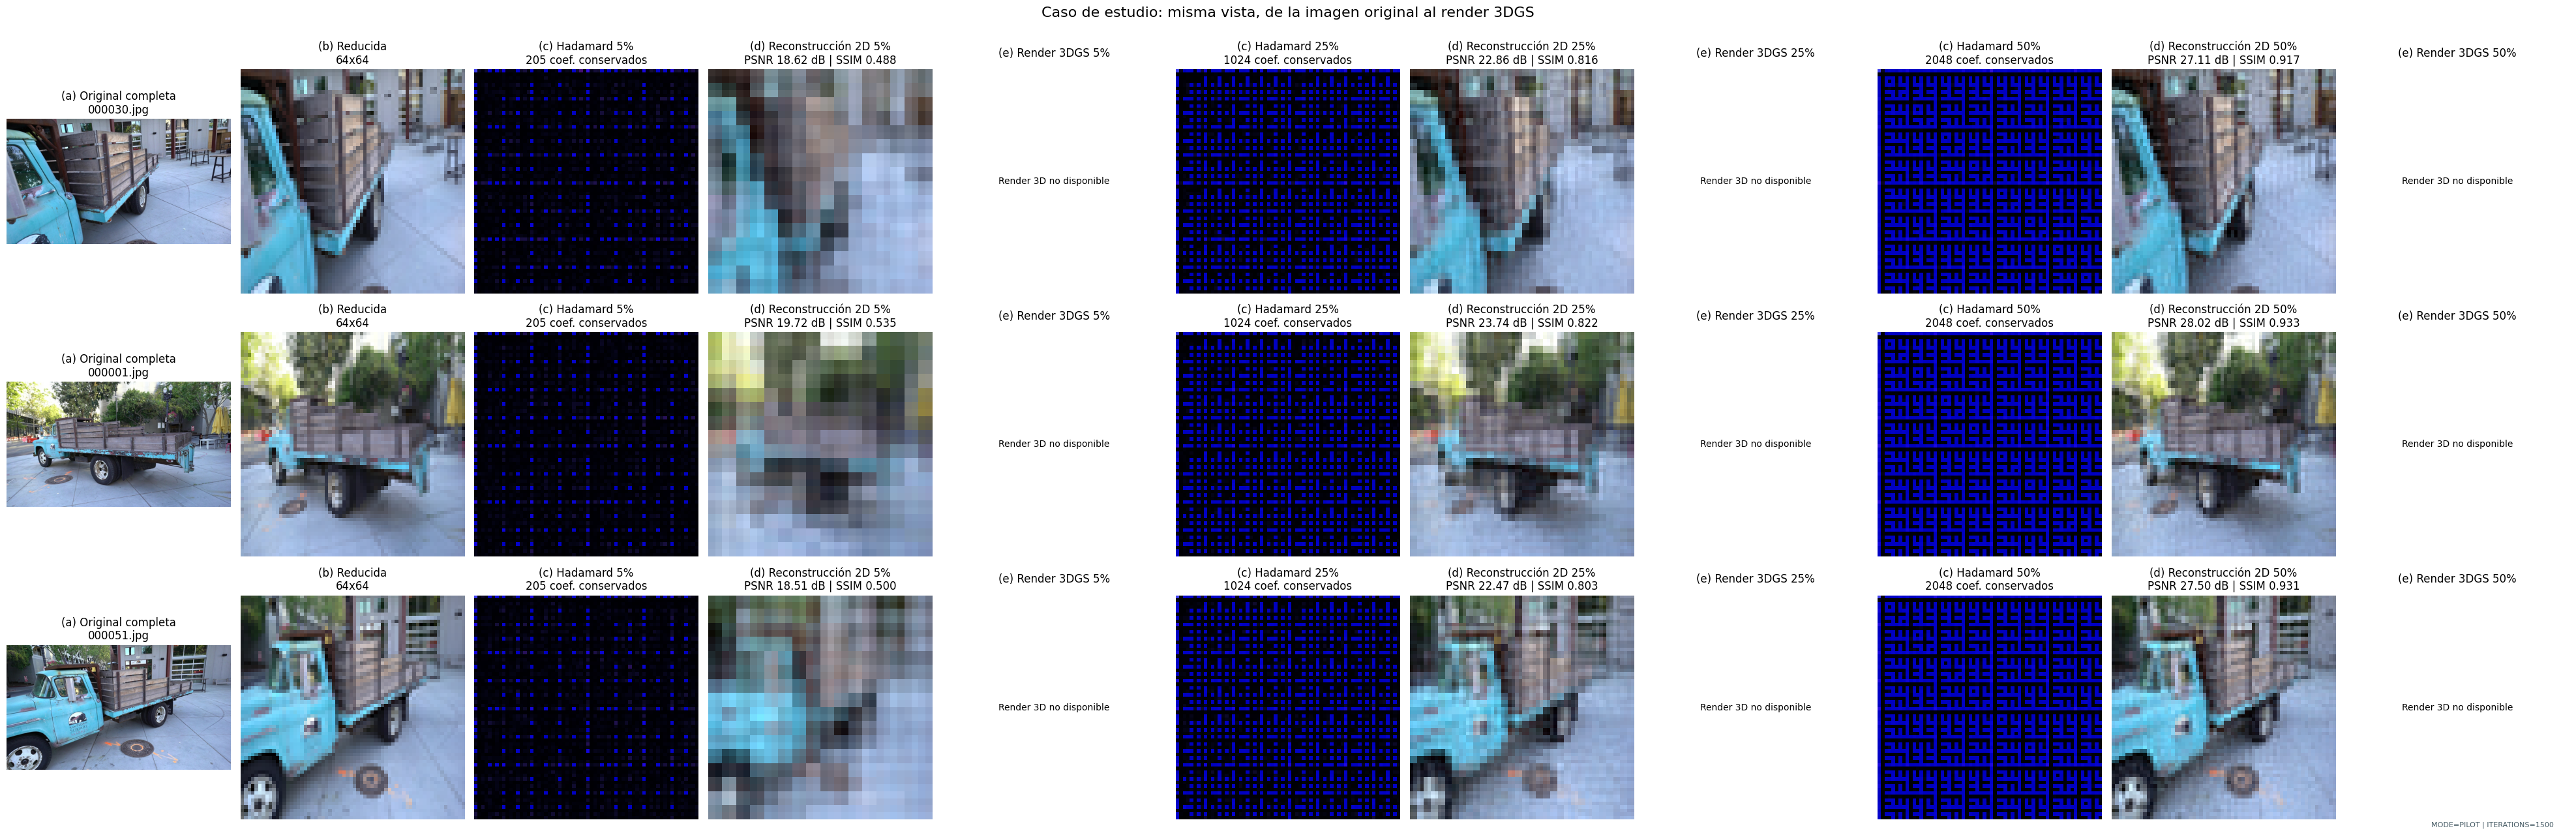

In [ ]:
# Esta figura solo se construye después de una corrida 3D validada.
if 'verification_df' not in globals() or verification_df.empty:
    raise RuntimeError('La demo 3D requiere ejecutar y aprobar primero la validación de OE4.')
if 'validation_errors' in globals() and validation_errors:
    raise RuntimeError('La demo 3D se detiene porque OE4 tiene errores: ' + ' | '.join(validation_errors))
if 'training_status_df' not in globals() or training_status_df.empty:
    raise RuntimeError('No hay estado de entrenamiento disponible; ejecuta OE4 antes de la demo.')
bad_training = training_status_df[
    ~training_status_df['estado_entrenamiento'].isin({'ok', 'reutilizado'})
    | ~training_status_df['estado_render'].eq('ok')
    | ~training_status_df['estado_metrics'].eq('ok')
]
if not bad_training.empty:
    raise RuntimeError(f'La demo 3D requiere todas las escenas aprobadas; fallas: {bad_training.to_dict(orient="records")}')

# En PILOT solo existe spc_025; en FULL se eligen tres niveles representativos.
available_case_study_ratios = [
    ratio for ratio in COMPRESSION_RATIOS
    if f'spc_{ratio_tag(ratio)}' in SCENE_FOLDERS
]
if not available_case_study_ratios:
    raise RuntimeError('No hay niveles SPC entrenados para construir la demo 3D.')
CASE_STUDY_RATIOS = list(dict.fromkeys([
    available_case_study_ratios[0],
    available_case_study_ratios[len(available_case_study_ratios) // 2],
    available_case_study_ratios[-1],
]))

# La referencia queda primero; añadimos extremos del recorrido como control visual.
CASE_STUDY_FILES = []
for candidate in [REFERENCE_FILE, image_files[0], image_files[-1]]:
    if candidate not in CASE_STUDY_FILES:
        CASE_STUDY_FILES.append(candidate)

def scene_name_for_ratio(ratio):
    return f'spc_{ratio_tag(ratio)}'

def three_d_average_caption(scene_name):
    if 'metrics_3d_original_df' not in globals() or metrics_3d_original_df.empty:
        return '3D: sin métricas originales'
    rows = metrics_3d_original_df[metrics_3d_original_df['escena'] == scene_name]
    if rows.empty:
        return '3D: sin métricas originales'
    row = rows.iloc[0]
    return f'3D vs original\nPSNR {row["psnr_3d_original_db"]:.2f} dB | SSIM {row["ssim_3d_original"]:.3f}'

n_columns = 2 + 3 * len(CASE_STUDY_RATIOS)
fig, axes = plt.subplots(
    len(CASE_STUDY_FILES), n_columns,
    figsize=(3.6 * n_columns, 4.2 * len(CASE_STUDY_FILES))
)
axes = np.atleast_2d(axes)

for row_index, view_file in enumerate(CASE_STUDY_FILES):
    view_working = load_image(view_file)
    view_original = load_original_image(view_file)
    view_coefficients = np.stack([
        H @ view_working[..., c] @ H.T
        for c in range(view_working.shape[-1])
    ], axis=-1)
    view_coefficient_magnitude = np.log1p(np.mean(np.abs(view_coefficients), axis=-1))

    axes[row_index, 0].imshow(view_original)
    axes[row_index, 0].set_title(f'(a) Original completa\n{view_file.name}')
    axes[row_index, 0].axis('off')
    axes[row_index, 1].imshow(view_working)
    axes[row_index, 1].set_title(f'(b) Reducida\n{IMAGE_SIZE[0]}x{IMAGE_SIZE[1]}')
    axes[row_index, 1].axis('off')

    for ratio_index, ratio in enumerate(CASE_STUDY_RATIOS):
        reconstruction, measurements = reconstruct_view(view_working, ratio)
        selected = HADAMARD_ORDER[:len(measurements)]
        selected_mask = np.zeros(view_coefficients.shape[:2], dtype=bool)
        for i, j in selected:
            selected_mask[i, j] = True
        psnr, ssim = compute_metrics(view_working, reconstruction)
        base = 2 + 3 * ratio_index

        axes[row_index, base].imshow(view_coefficient_magnitude, cmap='magma')
        axes[row_index, base].imshow(np.ma.masked_where(~selected_mask, selected_mask), cmap='winter', alpha=0.75, interpolation='nearest')
        axes[row_index, base].set_title(f'(c) Hadamard {ratio:.0%}\n{len(selected)} coef. conservados')
        axes[row_index, base].axis('off')

        axes[row_index, base + 1].imshow(reconstruction)
        axes[row_index, base + 1].set_title(f'(d) Reconstrucción 2D {ratio:.0%}\nPSNR {psnr:.2f} dB | SSIM {ssim:.3f}')
        axes[row_index, base + 1].axis('off')

        scene_name = scene_name_for_ratio(ratio)
        model_path = GS_OUTPUTS_ROOT / f'gs_{scene_name}'
        match = find_matching_render(model_path, view_file) if model_path.exists() else None
        if match is not None:
            axes[row_index, base + 2].imshow(Image.open(match['render_path']))
            axes[row_index, base + 2].set_title(f'(e) Render 3DGS {ratio:.0%}\n{three_d_average_caption(scene_name)}')
        else:
            axes[row_index, base + 2].text(0.5, 0.5, 'Render 3D no disponible', ha='center', va='center')
            axes[row_index, base + 2].set_title(f'(e) Render 3DGS {ratio:.0%}')
        axes[row_index, base + 2].axis('off')

fig.suptitle('Caso de estudio: misma vista, de la imagen original al render 3DGS', y=1.01, fontsize=16)
plt.tight_layout()
case_study_path = RESULTS_ROOT / 'caso_estudio_tira_pelicula.png'
fig.savefig(case_study_path, dpi=150, bbox_inches='tight')
print('Figura guardada en:', case_study_path)
if 'fig' in globals() and 'MODE' in globals():
    fig.text(0.99, 0.01, f'MODE={MODE} | ITERATIONS={ITERATIONS}', ha='right', va='bottom', fontsize=8, color='#455A64')
